# Bibliotecas y cofinguracion de graficos

In [2]:
import importlib
import subprocess
import sys

# Mapeo de imports → nombres reales de paquetes en pip
required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "seaborn": "seaborn",
    "statsmodels": "statsmodels",
    "sklearn": "scikit-learn",   
    "plotly": "plotly",
    "stargazer": "stargazer",
}

def safe_pip_install(package):
    """Instala un paquete si no está, sin actualizar."""
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        print(f"✓ {package} instalado correctamente.")
    except Exception:
        print(f"⚠ No se pudo instalar {package}. Puede estar bloqueado por Anaconda.")

def install_if_missing(import_name, pip_name):
    try:
        importlib.import_module(import_name)
        print(f"✔ {import_name} ya está instalado.")
    except ImportError:
        print(f"✖ {import_name} no está instalado. Instalando {pip_name}...")
        safe_pip_install(pip_name)

print("📦 Verificando librerías necesarias...\n")

for import_name, pip_name in required_packages.items():
    install_if_missing(import_name, pip_name)

print("\n🎉 Todas las librerías están listas.")


📦 Verificando librerías necesarias...

✔ numpy ya está instalado.
✔ pandas ya está instalado.
✔ matplotlib ya está instalado.
✔ scipy ya está instalado.
✔ seaborn ya está instalado.
✔ statsmodels ya está instalado.
✔ sklearn ya está instalado.
✔ plotly ya está instalado.
✔ stargazer ya está instalado.

🎉 Todas las librerías están listas.


In [3]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.stats import pointbiserialr
import seaborn as sns
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from scipy import stats
from IPython.core.display import display, HTML
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from IPython.display import clear_output, display
import warnings
from matplotlib.lines import Line2D

C:\Users\alexf\AppData\Local\Temp\ipykernel_23340\4258185179.py:14: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [4]:

warnings.filterwarnings("ignore")
PALETTE_NAME = "Accent"
HIST_GRAY = "0.38"  # histogr. en escala de grises (sin color de relleno)

sns.set_theme(style="whitegrid")
sns.set_palette(PALETTE_NAME)

plt.rc("font", size=12)
plt.rc("axes", titlesize=16, titleweight="bold")


def palette_n(n):
    # Colores discretos derivados de la paleta principal.
    n = max(int(n), 1)
    return sns.color_palette(PALETTE_NAME, n_colors=n)

# Limpieza de datos

In [5]:
df=pd.read_csv("data__movies.csv")
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4775 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   original_language     4803 non-null   object 
 5   original_title        4803 non-null   object 
 6   overview              4800 non-null   object 
 7   popularity            4803 non-null   float64
 8   production_companies  4452 non-null   object 
 9   release_date          4802 non-null   object 
 10  revenue               4803 non-null   int64  
 11  runtime               4801 non-null   float64
 12  status                4803 non-null   object 
 13  tagline               3959 non-null   object 
 14  title                 4803 non-null   object 
 15  vote_average         

## Limpieza de outlier y valores nulos

### contar outlier por columna

In [6]:
#contar outliers
def count_outliers(df):
    outlier_counts = {}
    for col in df.columns:

        if pd.api.types.is_numeric_dtype(df[col]):  # Solo columnas numéricas
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
            outlier_counts[col] = outliers
    outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier Count'])
    outlier_df = outlier_df.sort_values(by='Outlier Count', ascending=False)        
    return outlier_df

# Contar outliers en el DataFrame df
outlier_counts = count_outliers(df)
outlier_counts.head(20)

,Outlier Count
id,704
vote_count,504
revenue,472
budget,321
popularity,275
runtime,182
vote_average,156


### contar valores nulos

In [7]:
columnas = ["budget", "genres", "original_language", "popularity", "production_companies", "release_date", "revenue", "runtime", "vote_average", "vote_count"]

In [8]:
df1 = df[columnas]
df1["genres"].isna().sum()



28

In [9]:
#Dropeamos columnas NA en genres

df1 = df1.dropna(subset=['genres'])

### Limpieza de outliers en revenue
Limpiamos 0's, y el último cuantil

In [10]:
zero_revenue_count = (pd.to_numeric(df1['revenue'], errors='coerce') == 0).sum()
total_rows = len(df1)
print(f'Rows with revenue = 0: {zero_revenue_count}')
print(f'Percentage: {zero_revenue_count/total_rows:.2%}')
df1.drop(df1[pd.to_numeric(df1['revenue'], errors='coerce') == 0].index, inplace=True)

Rows with revenue = 0: 1400
Percentage: 29.32%


se pierde una cantidad sustancial de datos debido a eliminar ingresos nulos,si embargo estos datos no entregan informacion util sobre como se comportan los ingresos ya que al ser nulos lo unico que indican es que la pelicula probablemente no se estreno  

Revenue summary:
count    3.375000e+03
mean     1.170655e+08
std      1.834995e+08
min      5.000000e+00
25%      1.536924e+07
50%      5.180119e+07
75%      1.401684e+08
90%      3.028029e+08
95%      4.622882e+08
99%      9.021396e+08
max      2.787965e+09
Name: revenue, dtype: float64

--- Outlier Detection ---
Percentile 99 (Top 1%): > 902139643.72
Registros excluidos (Top 1%): 34
IQR bounds: [-171829511.0, 327367145.0]
IQR outliers: 299
Z-score outliers (|z|>3): 86

Top 15 highest Revenue:
        revenue
0    2787965087
25   1845034188
16   1519557910
28   1513528810
44   1506249360
7    1405403694
124  1274219009
31   1215439994
546  1156730962
26   1153304495
52   1123746996
329  1118888979
29   1108561013
36   1091405097
3    1084939099


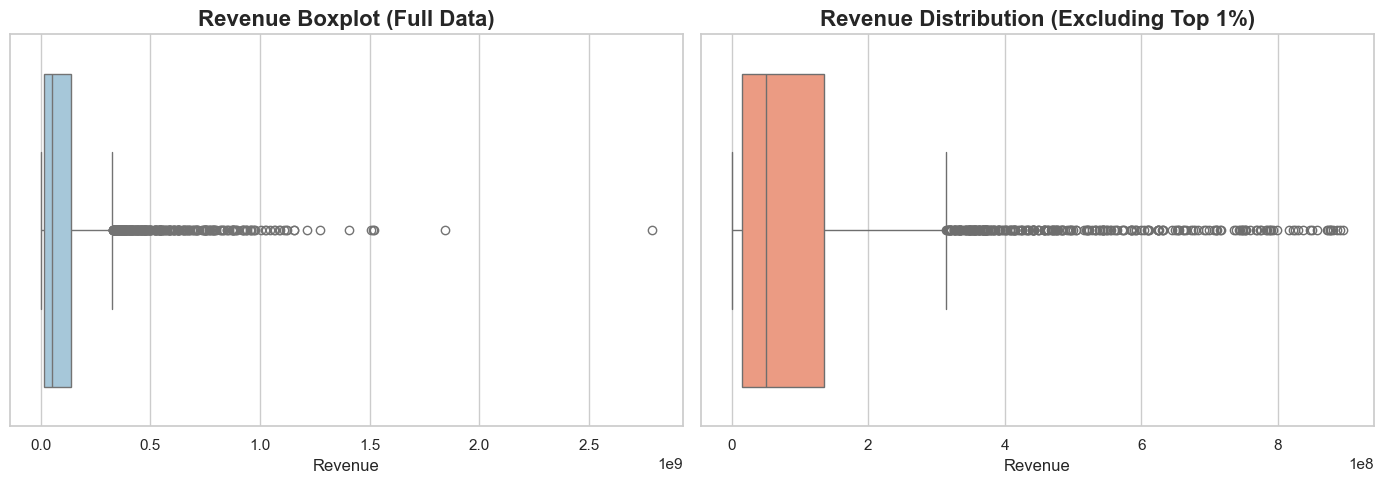

In [11]:
# 1. Limpieza de Revenue como numérico
revenue_clean = pd.to_numeric(df1['revenue'], errors='coerce')

# --- EXCLUSIÓN DEL ÚLTIMO 1% ---
q99 = revenue_clean.quantile(0.99)
outlier_99 = revenue_clean > q99

# 2. Método IQR
q1 = revenue_clean.quantile(0.25)
q3 = revenue_clean.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_iqr = (revenue_clean < lower) | (revenue_clean > upper)

# 3. Método Z-score (sobre valores no nulos)
mu = revenue_clean.mean()
sigma = revenue_clean.std()
z_scores = (revenue_clean - mu) / sigma
outlier_z = z_scores.abs() > 3

# --- IMPRESIÓN DE RESULTADOS ---
print('Revenue summary:')
print(revenue_clean.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

print('\n--- Outlier Detection ---')
print(f'Percentile 99 (Top 1%): > {round(q99, 2)}')
print(f'Registros excluidos (Top 1%): {int(outlier_99.sum())}')
print(f'IQR bounds: [{round(lower, 2)}, {round(upper, 2)}]')
print(f'IQR outliers: {int(outlier_iqr.sum())}')
print(f'Z-score outliers (|z|>3): {int(outlier_z.sum())}')

# Mostrar los 15 más altos
title_col = next((c for c in ['title', 'original_title', 'movie_title', 'name'] if c in df1.columns), None)
cols_to_show = ['revenue'] + ([title_col] if title_col else [])
print('\nTop 15 highest Revenue:')
print(df1.loc[revenue_clean.nlargest(15).index, cols_to_show])

# --- REVISIÓN VISUAL ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot original (con outliers)
sns.boxplot(x=revenue_clean.dropna(), ax=axes[0], color='#9ecae1')
axes[0].set_title('Revenue Boxplot (Full Data)')
axes[0].set_xlabel('Revenue')

# Boxplot sin outliers (excluyendo el último 1%)
revenue_no_outliers = revenue_clean[~outlier_99].dropna()  # ✅ Fix: variable separada
sns.boxplot(x=revenue_no_outliers, ax=axes[1], color='#fc9272')  # ✅ Fix: axes[1] en vez de axes[0]
axes[1].set_title('Revenue Distribution (Excluding Top 1%)')
axes[1].set_xlabel('Revenue')

plt.tight_layout()
plt.show()

notar que no existe un cambio sustancial en la distribucion de los datos al quitar el percentil 99 de estos,ademas se puede ver que los datos son muy dispersor entre si debido a su naturaleza,por lo tanto no se justifica eliminar estos outlier ya que podria aportar informacion sobre peliculas mega exitosas.

### limpieza de outlier en budget
Limpiamos 0's, y el último cuantil

In [12]:
zero_budget_count = (pd.to_numeric(df1['budget'], errors='coerce') == 0).sum()
total_rows = len(df1)
print(f'Rows with budget = 0: {zero_budget_count}')
print(f'Percentage: {zero_budget_count/total_rows:.2%}')
df1.drop(df1[pd.to_numeric(df1['budget'], errors='coerce') == 0].index, inplace=True)

Rows with budget = 0: 147
Percentage: 4.36%


mismo proceso que con revenue,notar que en este caso al ser poco datos nulos la perdida da filas informacion util es minima

Budget summary:
count    3.228000e+03
mean     4.066642e+07
std      4.439840e+07
min      1.000000e+00
25%      1.050000e+07
50%      2.500000e+07
75%      5.500000e+07
90%      9.500000e+07
95%      1.400000e+08
99%      2.000000e+08
max      3.800000e+08
Name: budget, dtype: float64

--- Outlier Detection for Budget ---
Percentile 99 (Top 1%): > 200000000.0
Registros excluidos (Top 1%): 27
IQR bounds: [-56250000.0, 121750000.0]
IQR outliers: 216
Z-score outliers (|z|>3): 76

Top 15 highest Budgets:
       budget
17  380000000
1   300000000
7   280000000
10  270000000
4   260000000
6   260000000
5   258000000
13  255000000
3   250000000
8   250000000
9   250000000
19  250000000
22  250000000
26  250000000
46  250000000


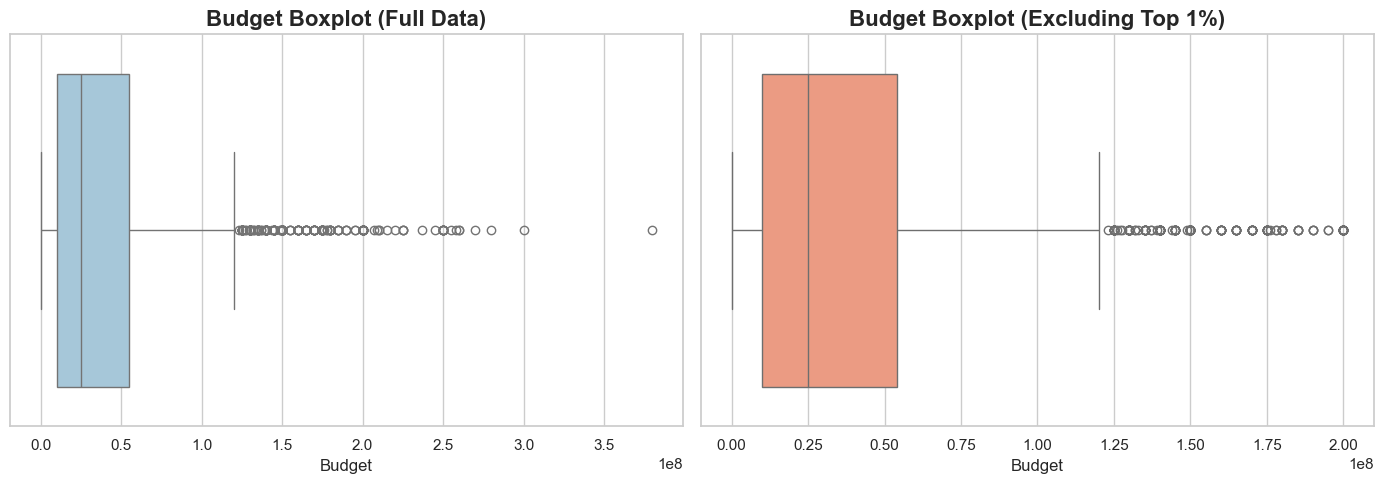

In [13]:
# 1. Limpieza de Budget como numérico
budget_clean = pd.to_numeric(df1['budget'], errors='coerce')

# --- EXCLUSIÓN DEL ÚLTIMO 1% (Percentil 99) ---
q99_budget = budget_clean.quantile(0.99)
outlier_99_budget = budget_clean > q99_budget

# 2. Método IQR
q1 = budget_clean.quantile(0.25)
q3 = budget_clean.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_iqr = (budget_clean < lower) | (budget_clean > upper)

# 3. Método Z-score (sobre valores no nulos)
mu = budget_clean.mean()
sigma = budget_clean.std()
z_scores = (budget_clean - mu) / sigma
outlier_z = z_scores.abs() > 3

# --- IMPRESIÓN DE RESULTADOS ---
print('Budget summary:')
print(budget_clean.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

print('\n--- Outlier Detection for Budget ---')
print(f'Percentile 99 (Top 1%): > {round(q99_budget, 2)}')
print(f'Registros excluidos (Top 1%): {int(outlier_99_budget.sum())}')
print(f'IQR bounds: [{round(lower, 2)}, {round(upper, 2)}]')
print(f'IQR outliers: {int(outlier_iqr.sum())}')
print(f'Z-score outliers (|z|>3): {int(outlier_z.sum())}')

# Mostrar los 15 presupuestos más altos
title_col = next((c for c in ['title', 'original_title', 'movie_title', 'name'] if c in df1.columns), None)
cols_to_show = ['budget'] + ([title_col] if title_col else [])
print('\nTop 15 highest Budgets:')
print(df1.loc[budget_clean.nlargest(15).index, cols_to_show])

# --- REVISIÓN VISUAL ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot original (con outliers)
sns.boxplot(x=budget_clean.dropna(), ax=axes[0], color='#9ecae1')  # ✅ Fix: .dropna()
axes[0].set_title('Budget Boxplot (Full Data)')
axes[0].set_xlabel('Budget')

# Boxplot sin outliers (excluyendo el último 1%)
budget_no_outliers = budget_clean[~outlier_99_budget].dropna()  # ✅ Fix: variable separada
sns.boxplot(x=budget_no_outliers, ax=axes[1], color='#fc9272')  # ✅ Fix: boxplot en vez de histplot
axes[1].set_title('Budget Boxplot (Excluding Top 1%)')
axes[1].set_xlabel('Budget')

plt.tight_layout()
plt.show()



denuevo se puede apreciar que la distribucion de revenue es bastante dispersa por lo que quitar outlier del percentil 99 podria eliminar informacion sobre mega produccion que puede ser util para el analisis,por lo tanto no se elimina.

## Encoding de variables categoricas

### clasificacion por lenguanje

*Hago one-hot en 'original language', 1 - Inglés, 0 - E.O.C*

In [14]:
df1["original_language"].value_counts()
df1["main_language_english"] = df1["original_language"].apply(lambda x: "1" if x == "en" else "0")


### Estudiamos el efecto del estudio y productora que produce las películas

In [15]:
df1["production_companies"].value_counts().head(30)

production_companies
Paramount Pictures                                                 48
Universal Pictures                                                 35
New Line Cinema                                                    29
Columbia Pictures                                                  28
Twentieth Century Fox Film Corporation                             25
Metro-Goldwyn-Mayer (MGM)                                          24
Warner Bros.                                                       24
Walt Disney Pictures                                               18
Touchstone Pictures                                                15
Columbia Pictures Corporation                                      13
Dimension Films                                                    13
DreamWorks Animation                                               12
Walt Disney Pictures, Pixar Animation Studios                      11
United Artists                                                     10

**Observamos que no existe una gran disparidad en la cantidad de películas realizadas por cada estudio, por lo tanto se estudiara si este comportarmiento se repite con las productoras**

In [16]:

studio_long = (
    df1[['production_companies']]
    .dropna()
    .assign(production_companies=lambda d: d['production_companies'].str.split(',\s*'))
    .explode('production_companies')
)

studio_long['production_companies'] = studio_long['production_companies'].str.strip()
studio_long = studio_long[studio_long['production_companies'] != '']

studio_counts = (
    studio_long['production_companies']
    .value_counts()
    .rename_axis('studio')
    .reset_index(name='total_movies')
)

studio_counts.head(30)

,studio,total_movies
0,Warner Bros.,280
1,Universal Pictures,273
2,Paramount Pictures,245
3,Twentieth Century Fox Film Corporation,201
4,Columbia Pictures,167
5,New Line Cinema,142
6,Relativity Media,100
7,Walt Disney Pictures,96
8,Touchstone Pictures,93
9,Metro-Goldwyn-Mayer (MGM),92


en este caso se aprecia que existe una gran diferencia entre el top 3 productoras y el resto.

### clasificacion por estudio famoso
Consideramos estudio famoso si cumple con 'total movies' > 90

In [17]:
studios_over_90 = set(studio_counts.loc[studio_counts['total_movies'] > 90, 'studio'])

def has_big_studio(companies):
    if pd.isna(companies):
        return 0
    studios = [s.strip() for s in str(companies).split(',') if s.strip()]
    return int(any(studio in studios_over_90 for studio in studios))

df1['big_studio'] = df1['production_companies'].apply(has_big_studio)
df1[['production_companies', 'big_studio']].head(10)

,production_companies,big_studio
0,"Ingenious Film Partners, Twentieth Century Fox...",1
1,"Walt Disney Pictures, Jerry Bruckheimer Films,...",1
2,"Columbia Pictures, Danjaq, B24",1
3,"Legendary Pictures, Warner Bros., DC Entertain...",1
4,Walt Disney Pictures,1
5,"Columbia Pictures, Laura Ziskin Productions, M...",1
6,"Walt Disney Pictures, Walt Disney Animation St...",1
7,"Marvel Studios, Prime Focus, Revolution Sun St...",0
8,"Warner Bros., Heyday Films",1
9,"DC Comics, Atlas Entertainment, Warner Bros., ...",1


In [18]:
df1["big_studio"].value_counts()

big_studio
0    1664
1    1564
Name: count, dtype: int64

### clasificacion de fechas

se separa la columna fechas para obterner mes,año,temporada y si el dias es laboral o no.

In [19]:
# Handle possible typo in column name
if 'release_date' in df1.columns:
    date_col = 'release_date'
elif 'relase_date' in df1.columns:
    date_col = 'relase_date'
else:
    raise KeyError("No release date column found. Expected 'release_date' or 'relase_date'.")

# 1) Standardize to datetime and YYYY-MM-DD
release_dt = pd.to_datetime(df1[date_col], errors='coerce')
df1['release_date_std'] = release_dt.dt.strftime('%Y-%m-%d')

# 2) Extract year
df1['release_year'] = release_dt.dt.year

# 3) Extract month name (e.g., October)
df1['release_month'] = release_dt.dt.month_name()

# 4) One-hot flag for business day
# Business day: Monday(0) to Friday(4)
df1['is_business_day_release'] = release_dt.dt.weekday.isin([0, 1, 2, 3, 4]).astype('Int64')

# 5) Season grouping based on month
# Northern Hemisphere seasons (United States)
# Winter:  Dec, Jan, Feb
# Spring:  Mar, Apr, May
# Summer:  Jun, Jul, Aug
# Fall:    Sep, Oct, Nov
def get_season(month):
    if pd.isna(month):
        return pd.NA
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Other'

df1['release_season'] = release_dt.dt.month.map(get_season)

# 6) Years since release
current_year = pd.Timestamp.now().year
df1['antiguedad'] = current_year - df1['release_year']

df1[[date_col, 'release_date_std', 'release_year', 'release_month', 'release_season', 'is_business_day_release', 'antiguedad']].head(10)

,release_date,release_date_std,release_year,release_month,release_season,is_business_day_release,antiguedad
0,2009-12-10,2009-12-10,2009,December,Winter,1,17
1,2007-05-19,2007-05-19,2007,May,Spring,0,19
2,2015-10-26,2015-10-26,2015,October,Fall,1,11
3,2012-07-16,2012-07-16,2012,July,Summer,1,14
4,2012-03-07,2012-03-07,2012,March,Spring,1,14
5,2007-05-01,2007-05-01,2007,May,Spring,1,19
6,2010-11-24,2010-11-24,2010,November,Fall,1,16
7,2015-04-22,2015-04-22,2015,April,Spring,1,11
8,2009-07-07,2009-07-07,2009,July,Summer,1,17
9,2016-03-23,2016-03-23,2016,March,Spring,1,10


### Clasificicacion por generos
one hot encoding de la colunna generos

In [20]:
df1['genres'].value_counts().head(30)

genres
Drama                                 204
Comedy                                197
Drama, Romance                         96
Comedy, Romance                        87
Comedy, Drama                          70
Comedy, Drama, Romance                 63
Horror, Thriller                       61
Horror                                 36
Drama, Thriller                        35
Action, Thriller                       32
Drama, History                         32
Crime, Drama, Thriller                 30
Action, Crime, Thriller                25
Adventure, Action, Thriller            24
Drama, Comedy                          24
Documentary                            22
Comedy, Crime                          22
Drama, Crime                           22
Comedy, Family                         21
Crime, Drama                           21
Animation, Family                      20
Action, Crime, Drama, Thriller         20
Drama, Comedy, Romance                 20
Animation, Comedy, Family  

In [21]:
genre_counts = (
    df['genres']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .loc[lambda s: s.ne('')]
    .value_counts()
)

genre_counts

genres
Drama              2297
Comedy             1722
Thriller           1274
Action             1154
Romance             894
Adventure           790
Crime               696
Science Fiction     535
Horror              519
Family              513
Fantasy             424
Mystery             348
Animation           234
History             197
Music               185
War                 144
Documentary         110
Western              82
Foreign              34
TV Movie              8
Name: count, dtype: int64

**Mapeamos los géneros y los agrupamos**

In [22]:
genre_map = {
    'science fiction': 'Fantasy',
    'thriller': 'Horror',
    'mystery': 'Crime',
    'music': 'Other',
    'war': 'Other',
    'documentary': 'Other',
    'western': 'Other',
    'foreign': 'Other',
    'tv movie': 'Other',
    'animation' : 'Family',
    'history' : 'Other'
}

genre_counts_generalized = (
    df['genres']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .loc[lambda s: s.ne('')]
    .map(lambda g: genre_map.get(g.lower(), g))
    .value_counts()
)


genre_counts_generalized


genres
Drama        2297
Horror       1793
Comedy       1722
Action       1154
Crime        1044
Fantasy       959
Romance       894
Adventure     790
Other         760
Family        747
Name: count, dtype: int64

In [23]:
#Ahora creamos una columna one-hot para cada género generalizado, asignando 1 si la película pertenece a ese género y 0 en caso contrario.
for genre in genre_counts_generalized.index:
    df1[f'genre_{genre}'] = df1['genres'].apply(
        lambda x: 1 if pd.notna(x) and genre in [
            genre_map.get(g.strip().lower(), g.strip())
            for g in x.split(',')
        ] else 0
    )
df1.head()

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,...,genre_Drama,genre_Horror,genre_Comedy,genre_Action,genre_Crime,genre_Fantasy,genre_Romance,genre_Adventure,genre_Other,genre_Family
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800,...,0,0,0,1,0,1,0,1,0,0
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500,...,0,0,0,1,0,1,0,1,0,0
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466,...,0,0,0,1,1,0,0,1,0,0
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106,...,1,1,0,1,1,0,0,0,0,0
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124,...,0,0,0,1,0,1,0,1,0,0


## Transformacion de variables

se trasformas variables con mucho outlier para mejorar su conportamiento sin la necesidad de perder datos

### estudio de budget

*Creamos Log-Budget*
log1p(budget) first: budget_log = log(1 + budget)

In [24]:
log_budget = np.log(1 + df1['budget'].dropna())
log_budget.describe()

count    3228.000000
mean       16.800614
std         1.661577
min         0.693147
25%        16.166886
50%        17.034386
75%        17.822844
max        19.755682
Name: budget, dtype: float64

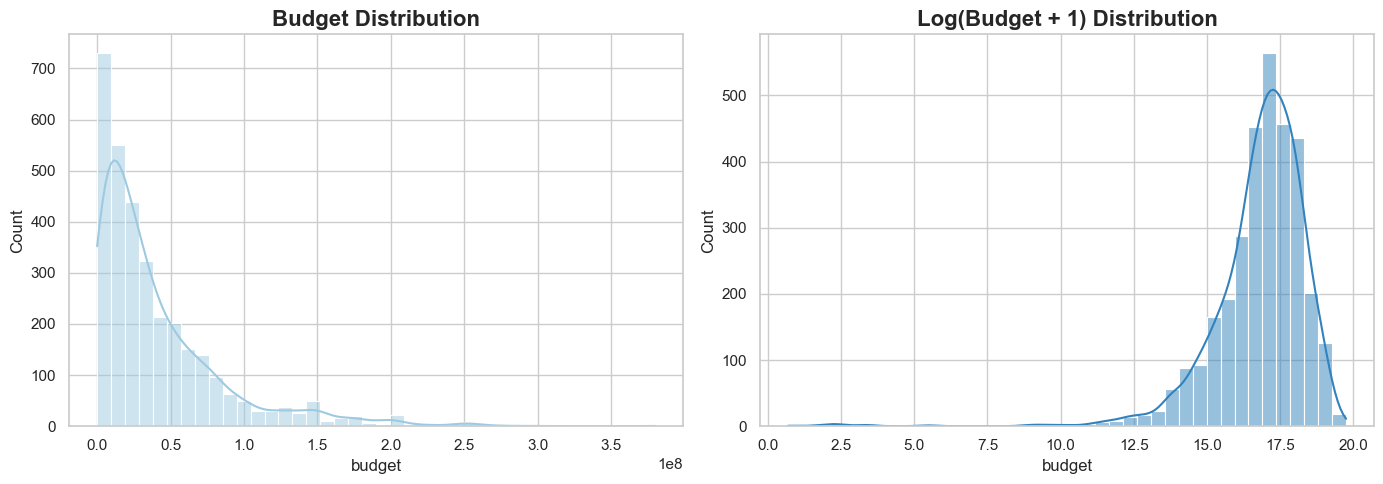

In [25]:
#Creamos un plot de budget y otro de budget logarítmico para comparar la distribución y detectar mejor los outliers.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df1['budget'].dropna(), bins=40, kde=True, ax=axes[0], color='#9ecae1')
axes[0].set_title('Budget Distribution')   
sns.histplot(log_budget, bins=40, kde=True, ax=axes[1], color='#3182bd')
axes[1].set_title('Log(Budget + 1) Distribution')
plt.tight_layout()
plt.show()  

In [26]:
#Ahora se puede observar que la distribución logarítmica es más simétrica y tiene menos outliers extremos, lo que facilita el análisis estadístico y la modelización. Usaremos standard scaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
log_budget_scaled = scaler.fit_transform(log_budget.values.reshape(-1, 1))
df1['log_budget_scaled'] = log_budget_scaled
df1.head()

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,...,genre_Horror,genre_Comedy,genre_Action,genre_Crime,genre_Fantasy,genre_Romance,genre_Adventure,genre_Other,genre_Family,log_budget_scaled
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800,...,0,0,1,0,1,0,1,0,0,1.494570
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500,...,0,0,1,0,1,0,1,0,0,1.636458
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466,...,0,0,1,1,0,0,1,0,0,1.514553
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106,...,1,0,1,1,0,0,0,0,0,1.526713
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124,...,0,0,1,0,1,0,1,0,0,1.550321


### estudiamos popularity

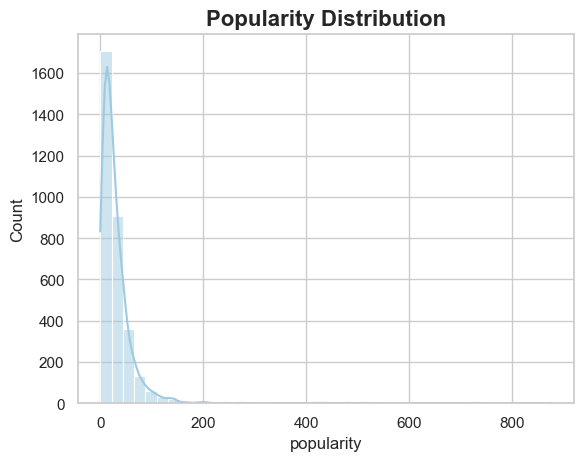

In [27]:
#Ploteamos la columna popularity para observar su distribución y detectar posibles outliers.
sns.histplot(df1['popularity'].dropna(), bins=40, kde=True, color='#9ecae1')
plt.title('Popularity Distribution')
plt.show()

In [28]:
#Aplicamos logaritmo a popularity para reducir la asimetría y facilitar el análisis estadístico.
log_popularity = np.log(1 + df1['popularity'].dropna())

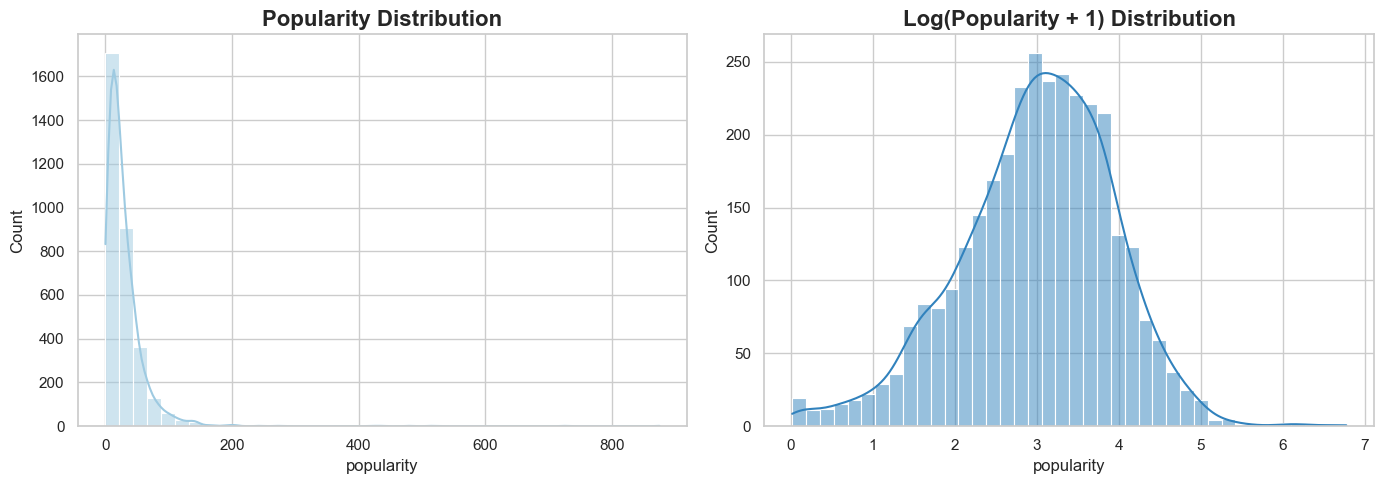

In [29]:
#Creamos un plot de popularity y otro de popularity logarítmico para comparar la distribución y detectar mejor los outliers.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df1['popularity'].dropna(), bins=40, kde=True, ax=axes[0], color='#9ecae1')
axes[0].set_title('Popularity Distribution')
sns.histplot(log_popularity, bins=40, kde=True, ax=axes[1], color='#3182bd')
axes[1].set_title('Log(Popularity + 1) Distribution')
plt.tight_layout()
plt.show()

In [30]:
#Aplicamos StandardScaler a popularity logarítmico para normalizarlo.
log_popularity_scaled = scaler.fit_transform(log_popularity.values.reshape(-1, 1))
df1["log_popularity_scaled"] = log_popularity_scaled
df1.head()

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,...,genre_Comedy,genre_Action,genre_Crime,genre_Fantasy,genre_Romance,genre_Adventure,genre_Other,genre_Family,log_budget_scaled,log_popularity_scaled
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800,...,0,1,0,1,0,1,0,0,1.494570,2.159066
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500,...,0,1,0,1,0,1,0,0,1.636458,2.075846
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466,...,0,1,1,0,0,1,0,0,1.514553,1.801847
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106,...,0,1,1,0,0,0,0,0,1.526713,1.849404
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124,...,0,1,0,1,0,1,0,0,1.550321,0.861632


### Estudiamos vote count

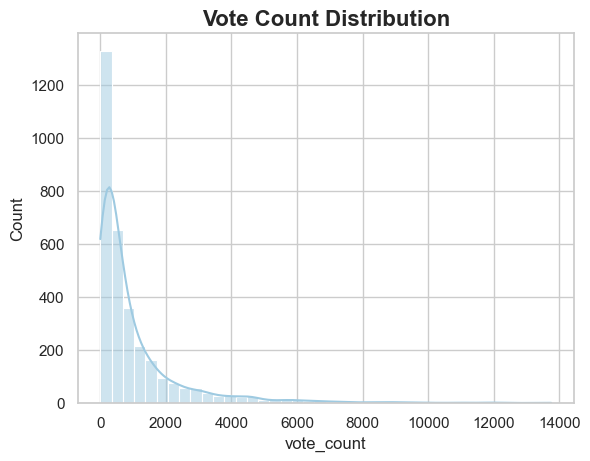

In [31]:
#Creamos un histograma de vote_count para observar su distribución y detectar posibles outliers.
sns.histplot(df1['vote_count'].dropna(), bins=40, kde=True, color='#9ecae1')
plt.title('Vote Count Distribution')
plt.show()

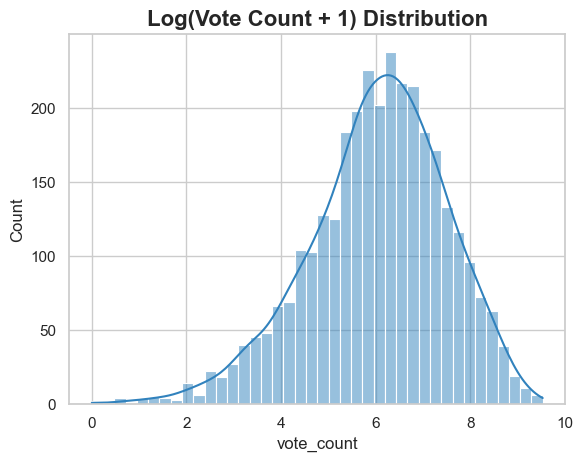

In [32]:
#Aplicamos logaritmo a vote_count para reducir la asimetría y facilitar el análisis estadístico.
log_vote_count = np.log(1 + df1['vote_count'].dropna())
#Revisamos el histograma de vote_count logarítmico para confirmar que la transformación ha reducido la asimetría y los outliers extremos.
sns.histplot(log_vote_count, bins=40, kde=True, color='#3182bd')
plt.title('Log(Vote Count + 1) Distribution')  
plt.show()

In [33]:
#Escalamos vote_count logarítmico con StandardScaler para normalizarlo.
log_vote_count_scaled = scaler.fit_transform(log_vote_count.values.reshape(-1, 1))
df1['log_vote_count_scaled'] = log_vote_count_scaled
df1.head()

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,...,genre_Action,genre_Crime,genre_Fantasy,genre_Romance,genre_Adventure,genre_Other,genre_Family,log_budget_scaled,log_popularity_scaled,log_vote_count_scaled
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800,...,1,0,1,0,1,0,0,1.494570,2.159066,2.301360
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500,...,1,0,1,0,1,0,0,1.636458,2.075846,1.637068
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466,...,1,1,0,0,1,0,0,1.514553,1.801847,1.631842
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106,...,1,1,0,0,0,0,0,1.526713,1.849404,2.122765
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124,...,1,0,1,0,1,0,0,1.550321,0.861632,1.119818


### Estudiamos Revenue

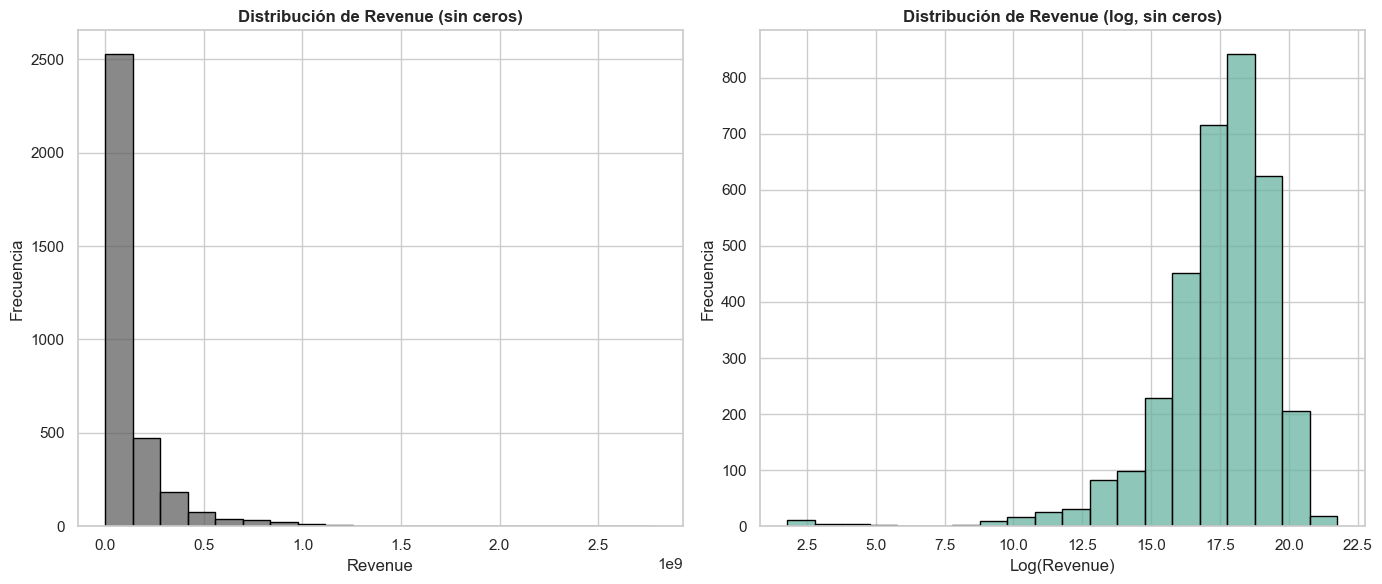

In [34]:
#Aplicamos logaritmo a revenue para reducir la asimetría y facilitar el análisis estadístico.
log_revenue = np.log(1 + df1['revenue'].dropna())

sns.set_theme(style="whitegrid")

#  Filtrar ceros
df_sin_ceros = df[df["revenue"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# 📊 Histograma normal (sin ceros)
sns.histplot(
    df_sin_ceros["revenue"],
    bins=20,
    color="0.38",
    edgecolor="black",
    ax=axes[0]
)

axes[0].set_title("Distribución de Revenue (sin ceros)")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Frecuencia")

# 📊 Histograma log (sin ceros)
sns.histplot(
    np.log1p(df_sin_ceros["revenue"]),
    bins=20,
    color="#69b3a2",
    edgecolor="black",
    ax=axes[1]
)

axes[1].set_title("Distribución de Revenue (log, sin ceros)")
axes[1].set_xlabel("Log(Revenue)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()

plt.show()

In [35]:
df1["log_revenue"] = log_revenue
df1.head()

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,...,genre_Crime,genre_Fantasy,genre_Romance,genre_Adventure,genre_Other,genre_Family,log_budget_scaled,log_popularity_scaled,log_vote_count_scaled,log_revenue
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800,...,0,1,0,1,0,0,1.494570,2.159066,2.301360,21.748578
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500,...,0,1,0,1,0,0,1.636458,2.075846,1.637068,20.683485
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466,...,1,0,0,1,0,0,1.514553,1.801847,1.631842,20.596199
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106,...,1,0,0,0,0,0,1.526713,1.849404,2.122765,20.804790
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124,...,0,1,0,1,0,0,1.550321,0.861632,1.119818,19.464974


# estadistica descriptiva

## Estudio ROI

### Estudio ROI y ingresos por inversion realizada

In [36]:
#Create a ROI column as (Revenue - Budget) / Budget
df1['ROI'] = (df1['revenue'] - df1['budget']) / df1['budget']
#Create 10 quantiles for ROI column
df1['ROI_quantile'] = pd.qcut(df1['ROI'], 10, labels=False)
df1[['revenue', 'budget', 'ROI']].tail(10)


,revenue,budget,ROI
4738,3221152,60000,52.685867
4742,28575078,65000,438.616585
4752,416498,65000,5.407662
4758,600896,4000000,-0.849776
4772,10000,31192,-0.679405
4773,3151130,27000,115.708519
4788,6000000,12000,499.000000
4792,99000,20000,3.950000
4796,424760,7000,59.680000
4798,2040920,220000,8.276909


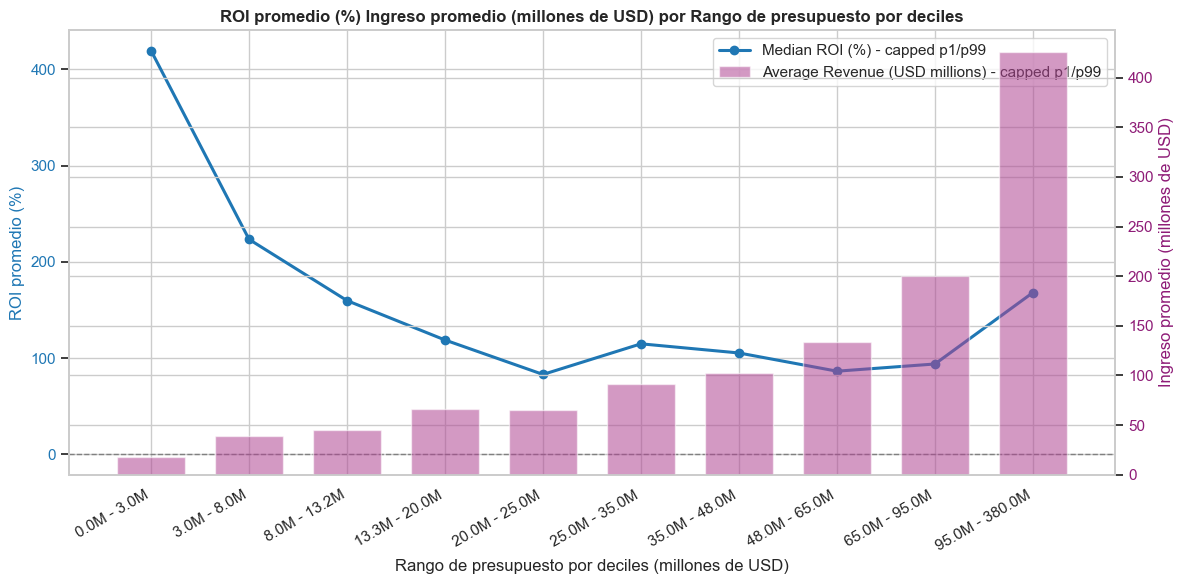

In [37]:
# Plot principal: ROI (%) y revenue promedio por deciles de presupuesto
plot_df = df1[['budget', 'revenue']].copy()
plot_df = plot_df[(plot_df['budget'] > 0) & (plot_df['revenue'] >= 0)]

# ROI en porcentaje
plot_df['ROI_pct'] = ((plot_df['revenue'] - plot_df['budget']) / plot_df['budget']) * 100

# Cap 1-99 percentil para reducir sesgo por extremos (ROI y Revenue)
roi_p1 = plot_df['ROI_pct'].quantile(0.01)
roi_p99 = plot_df['ROI_pct'].quantile(0.99)
plot_df['ROI_pct_capped'] = plot_df['ROI_pct'].clip(lower=roi_p1, upper=roi_p99)

rev_p1 = plot_df['revenue'].quantile(0.01)
rev_p99 = plot_df['revenue'].quantile(0.99)
plot_df['revenue_capped'] = plot_df['revenue'].clip(lower=rev_p1, upper=rev_p99)

# Deciles 1-10 garantizados usando ranking
plot_df['budget_decile'] = pd.qcut(
    plot_df['budget'].rank(method='first'),
    q=10,
    labels=range(1, 11)
).astype(int)

# Resumen por decil: mediana ROI capeada, revenue promedio capeado y extremos de budget
summary_decile = (
    plot_df.groupby('budget_decile', as_index=False)
    .agg(
        median_roi_pct=('ROI_pct_capped', 'median'),
        avg_revenue=('revenue_capped', 'mean'),
        budget_min=('budget', 'min'),
        budget_max=('budget', 'max')
    )
    .sort_values('budget_decile')
)

# Revenue en millones para escala legible
summary_decile['avg_revenue_m'] = summary_decile['avg_revenue'] / 1_000_000

# Etiquetas del eje X con extremos de cada decil
summary_decile['budget_range_label'] = (
    (summary_decile['budget_min'] / 1_000_000).round(1).astype(str)
    + 'M - '
    + (summary_decile['budget_max'] / 1_000_000).round(1).astype(str)
    + 'M'
)

x_pos = np.arange(len(summary_decile))

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Barras: revenue promedio capeado (eje derecho)
ax2.bar(
    x_pos,
    summary_decile['avg_revenue_m'],
    color="#af4593",
    alpha=0.55,
    width=0.7,
    label='Average Revenue (USD millions) - capped p1/p99'
)

# Línea: mediana ROI % capeada (eje izquierdo)
ax1.plot(
    x_pos,
    summary_decile['median_roi_pct'],
    marker='o',
    linewidth=2.2,
    color='#1f77b4',
    label='Median ROI (%) - capped p1/p99'
)

# Ejes y formato
ax1.set_xlabel('Rango de presupuesto por deciles (millones de USD)')
ax1.set_ylabel('ROI promedio (%)', color='#1f77b4')
ax2.set_ylabel('Ingreso promedio (millones de USD)', color="#8e1c77")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(summary_decile['budget_range_label'], rotation=30, ha='right')
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax2.tick_params(axis='y', labelcolor="#8e1c77")
ax1.set_title('ROI promedio (%) Ingreso promedio (millones de USD) por Rango de presupuesto por deciles')

# Leyenda combinada
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='best', frameon=True)

plt.tight_layout()
plt.show()

**Interpretación gráfico**

A medida que se invierte más budget en las películas, se esperan porcentajes de retornos a la inversión menores, sin embargo, ingresos mayores, que representan mayor utilidad.

### Estudio ROI por género

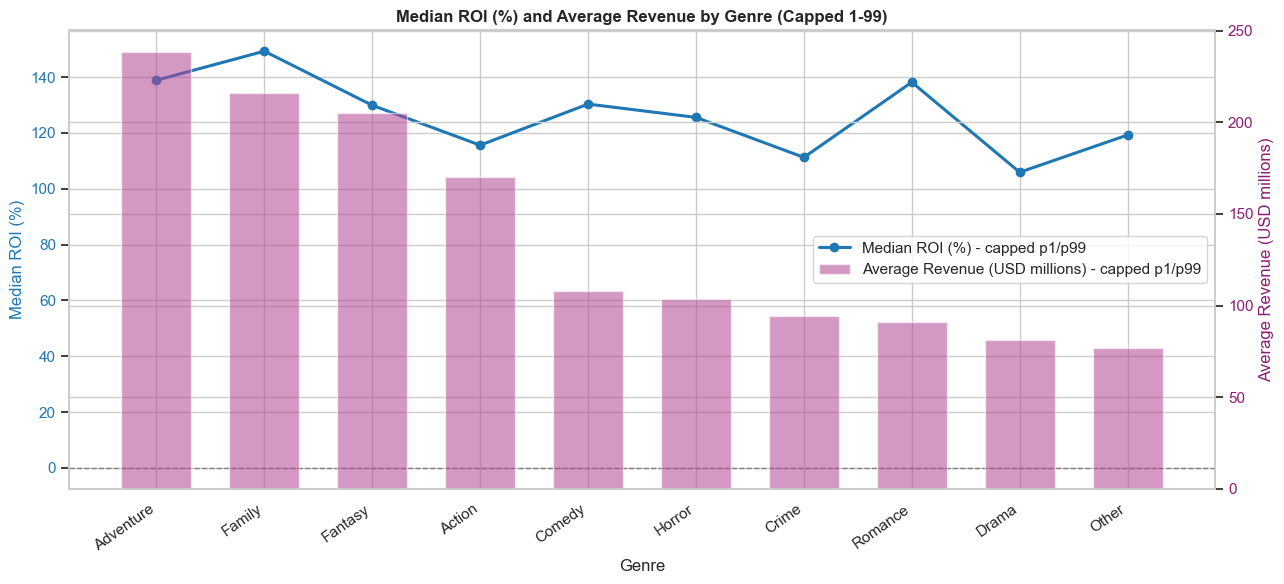

In [38]:
# Median ROI (%) and Avg Revenue by Genre (same capped 1-99 logic)
genre_cols = [c for c in df1.columns if c.startswith('genre_')]

# Base table with needed numeric fields
plot_df = df1[['budget', 'revenue'] + genre_cols].copy()
plot_df = plot_df[(plot_df['budget'] > 0) & (plot_df['revenue'] >= 0)]

# ROI in percentage
plot_df['ROI_pct'] = ((plot_df['revenue'] - plot_df['budget']) / plot_df['budget']) * 100

# Cap 1-99 percentile for both metrics
roi_p1 = plot_df['ROI_pct'].quantile(0.01)
roi_p99 = plot_df['ROI_pct'].quantile(0.99)
plot_df['ROI_pct_capped'] = plot_df['ROI_pct'].clip(lower=roi_p1, upper=roi_p99)

rev_p1 = plot_df['revenue'].quantile(0.01)
rev_p99 = plot_df['revenue'].quantile(0.99)
plot_df['revenue_capped'] = plot_df['revenue'].clip(lower=rev_p1, upper=rev_p99)

# Compute metrics per genre using one-hot membership
rows = []
for g in genre_cols:
    mask = plot_df[g] == 1
    if mask.any():
        rows.append({
            'genre': g.replace('genre_', ''),
            'median_roi_pct': plot_df.loc[mask, 'ROI_pct_capped'].median(),
            'avg_revenue_m': plot_df.loc[mask, 'revenue_capped'].mean() / 1_000_000,
            'n_movies': int(mask.sum())
        })

genre_summary = pd.DataFrame(rows).sort_values('avg_revenue_m', ascending=False).reset_index(drop=True)

# Plot with twin y-axes: ROI as line, revenue as bars
x_pos = np.arange(len(genre_summary))

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

# Bars for average revenue (right axis)
ax2.bar(
    x_pos,
    genre_summary['avg_revenue_m'],
    width=0.65,
    color='#af4593',
    alpha=0.55,
    label='Average Revenue (USD millions) - capped p1/p99'
 )

# Line for median ROI (left axis)
ax1.plot(
    x_pos,
    genre_summary['median_roi_pct'],
    marker='o',
    linewidth=2.2,
    color='#1f77b4',
    label='Median ROI (%) - capped p1/p99'
 )

ax1.set_xlabel('Genre')
ax1.set_ylabel('Median ROI (%)', color='#1f77b4')
ax2.set_ylabel('Average Revenue (USD millions)', color='#8e1c77')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(genre_summary['genre'], rotation=35, ha='right')
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax2.tick_params(axis='y', labelcolor='#8e1c77')
ax1.set_title('Median ROI (%) and Average Revenue by Genre (Capped 1-99)')

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='best', frameon=True)

plt.tight_layout()
plt.show()

### Estudio ROI por temporada

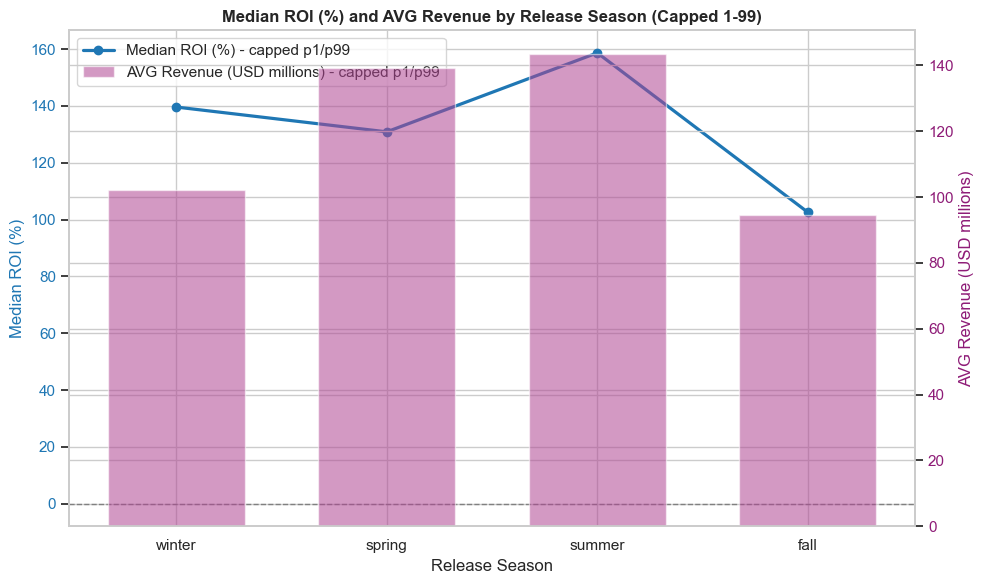

In [39]:
# Median ROI (%) and Avg Revenue by release season
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

# Base table
plot_df = df1[['release_season', 'budget', 'revenue']].copy()
plot_df = plot_df[
    (plot_df['budget'] > 0)
    & (plot_df['revenue'] >= 0)
    & (plot_df['release_season'].isin(season_order))
]

# ROI in percentage
plot_df['ROI_pct'] = ((plot_df['revenue'] - plot_df['budget']) / plot_df['budget']) * 100

# Cap 1-99 percentile for both metrics
roi_p1 = plot_df['ROI_pct'].quantile(0.01)
roi_p99 = plot_df['ROI_pct'].quantile(0.99)
plot_df['ROI_pct_capped'] = plot_df['ROI_pct'].clip(lower=roi_p1, upper=roi_p99)

rev_p1 = plot_df['revenue'].quantile(0.01)
rev_p99 = plot_df['revenue'].quantile(0.99)
plot_df['revenue_capped'] = plot_df['revenue'].clip(lower=rev_p1, upper=rev_p99)

# Aggregate by season in fixed order
season_summary = (
    plot_df.groupby('release_season', as_index=False)
    .agg(
        median_roi_pct=('ROI_pct_capped', 'median'),
        avg_revenue=('revenue_capped', 'mean')
    )
)
season_summary['release_season'] = pd.Categorical(
    season_summary['release_season'],
    categories=season_order,
    ordered=True
)
season_summary = season_summary.sort_values('release_season')
season_summary['avg_revenue_m'] = season_summary['avg_revenue'] / 1_000_000

x_pos = np.arange(len(season_summary))

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Bars: average revenue (right axis)
ax2.bar(
    x_pos,
    season_summary['avg_revenue_m'],
    color='#af4593',
    alpha=0.55,
    width=0.65,
    label='AVG Revenue (USD millions) - capped p1/p99'
)

# Line: median ROI (left axis)
ax1.plot(
    x_pos,
    season_summary['median_roi_pct'],
    marker='o',
    linewidth=2.3,
    color='#1f77b4',
    label='Median ROI (%) - capped p1/p99'
)

# Axes formatting
ax1.set_xlabel('Release Season')
ax1.set_ylabel('Median ROI (%)', color='#1f77b4')
ax2.set_ylabel('AVG Revenue (USD millions)', color='#8e1c77')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(['winter', 'spring', 'summer', 'fall'])
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax2.tick_params(axis='y', labelcolor='#8e1c77')
ax1.set_title('Median ROI (%) and AVG Revenue by Release Season (Capped 1-99)')

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

## Estudio de generos

### Grafico de generos con mayores revenues

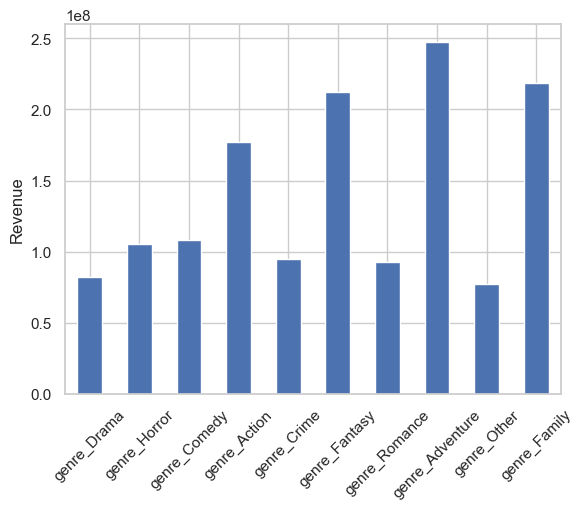

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

genre_cols = [col for col in df1.columns if col.startswith('genre_')]

revenues = {g: df1[df1[g]==1]['revenue'].mean() for g in genre_cols}

pd.Series(revenues).plot(kind='bar')

plt.xticks(rotation=45)
plt.ylabel('Revenue')
plt.show()

### generos con mayor popularidad

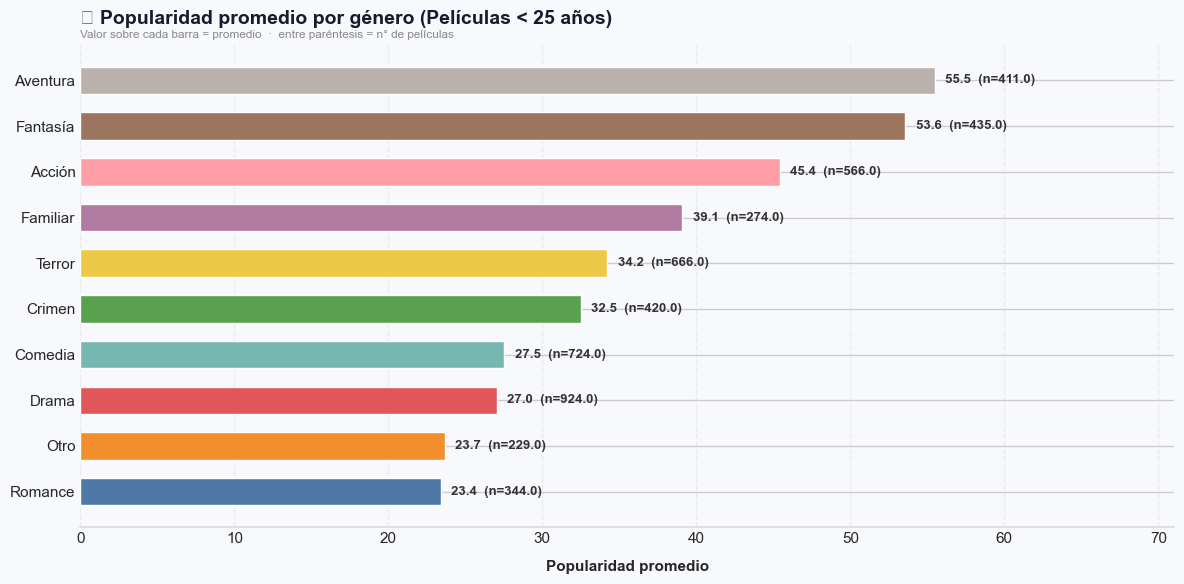

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime

# ── 0. Asegurar antiguedad ────────────────────────────────────────────────
if 'antiguedad' not in df1.columns:
    current_year = datetime.now().year
    df1['antiguedad'] = current_year - df1['release_year']

# ── 1. Filtrar películas (<25 años) ──────────────────────────────────────
df_filtered = df1[df1['antiguedad'] < 25].copy()

# ── 2. Preparar datos ────────────────────────────────────────────────────
genre_cols = {
    'genre_Action':    'Acción',
    'genre_Adventure': 'Aventura',
    'genre_Comedy':    'Comedia',
    'genre_Crime':     'Crimen',
    'genre_Drama':     'Drama',
    'genre_Family':    'Familiar',
    'genre_Fantasy':   'Fantasía',
    'genre_Horror':    'Terror',
    'genre_Romance':   'Romance',
    'genre_Other':     'Otro',
}

medias = {}
conteos  = {}

for col, nombre in genre_cols.items():
    if col in df_filtered.columns:
        vals = df_filtered.loc[df_filtered[col] == 1, 'popularity'].dropna()
        
        if len(vals) > 0:
            medias[nombre] = vals.mean()   # 👈 cambio clave
            conteos[nombre] = len(vals)

df_bar = (
    pd.DataFrame({'media': medias, 'n': conteos})
    .dropna()
    .sort_values('media', ascending=True)
)

# ── 3. Colores ───────────────────────────────────────────────────────────
colores = [
    '#4e79a7', '#f28e2b', '#e15759', '#76b7b2',
    '#59a14f', '#edc948', '#b07aa1', '#ff9da7',
    '#9c755f', '#bab0ac'
]

# ── 4. Figura ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

bars = ax.barh(
    df_bar.index,
    df_bar['media'],
    color=colores[:len(df_bar)],
    height=0.6,
    zorder=2,
)

# ── 5. Etiquetas ─────────────────────────────────────────────────────────
max_val = df_bar['media'].max()
offset = max_val * 0.012

for bar, (genero, row) in zip(bars, df_bar.iterrows()):
    ax.text(
        row['media'] + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{row['media']:.1f}  (n={row['n']:,})",
        va='center',
        ha='left',
        fontsize=9.5,
        fontweight='bold',
        color='#333333'
    )

# ── 6. Estética ───────────────────────────────────────────────────────────
ax.set_xlim(0, max_val * 1.28)
ax.set_xlabel('Popularidad promedio', fontsize=11,
              fontweight='bold', labelpad=10)

ax.set_title('🎬 Popularidad promedio por género (Películas < 25 años)',
             fontsize=14, fontweight='bold', pad=15,
             loc='left', color='#1a1a2e')

ax.text(0, 1.01,
        'Valor sobre cada barra = promedio  ·  entre paréntesis = n° de películas',
        transform=ax.transAxes, fontsize=8.5,
        color='#888888', va='bottom')

ax.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
ax.tick_params(axis='both', length=0, labelsize=11)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#dddddd')

plt.tight_layout()
plt.show()

## Estudio top productoras

### ingresos por productoras

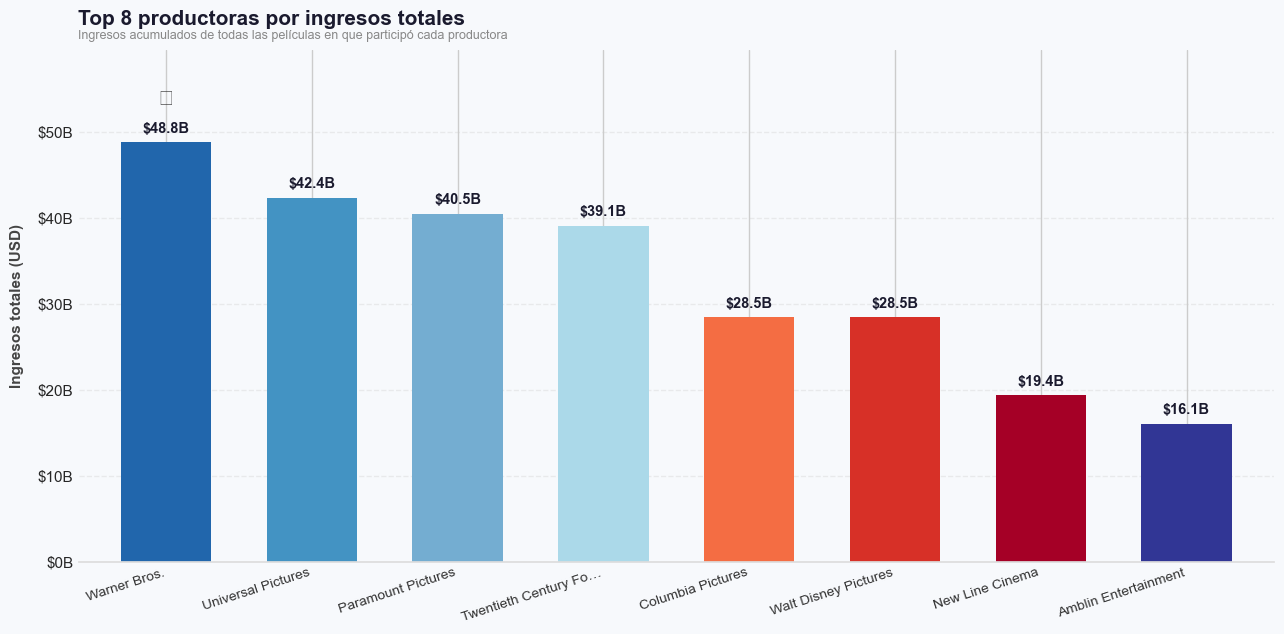

In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import ast

# ── 1. Parsear production_companies ──────────────────────────────────────
def extraer_companias(valor):
    if pd.isna(valor):
        return []
    try:
        lista = ast.literal_eval(valor)
        return [d['name'] for d in lista if isinstance(d, dict) and 'name' in d]
    except:
        return [c.strip() for c in str(valor).split(',') if c.strip()]

df_exp = df1[['production_companies', 'revenue']].copy()
df_exp['production_companies'] = df_exp['production_companies'].apply(extraer_companias)
df_exp = df_exp.explode('production_companies')
df_exp = df_exp[df_exp['production_companies'].notna() & (df_exp['production_companies'] != '')]

# ── 2. Top 8 por suma de ingresos ─────────────────────────────────────────
top8 = (df_exp.groupby('production_companies')['revenue']
              .sum()
              .sort_values(ascending=False)
              .head(8))

# Formatear en miles de millones
top8_b   = top8 / 1e9
etiquetas = top8_b.index.tolist()

# ── 3. Paleta ─────────────────────────────────────────────────────────────
colores = [
    '#2166ac', '#4393c3', '#74add1', '#abd9e9',
    '#f46d43', '#d73027', '#a50026', '#313695'
]

# ── 4. Figura ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

x      = np.arange(len(etiquetas))
altura = 0.62

bars = ax.bar(x, top8_b.values, width=altura,
              color=colores, zorder=2, linewidth=0)

# ── 5. Etiquetas encima de cada barra ────────────────────────────────────
for bar, val in zip(bars, top8_b.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + top8_b.max() * 0.015,
        f'${val:.1f}B',
        ha='center', va='bottom',
        fontsize=10.5, fontweight='bold', color='#1a1a2e'
    )

# ── 6. Medalla para el #1 ─────────────────────────────────────────────────
ax.annotate('🏆', xy=(x[0], top8_b.values[0]),
            xytext=(x[0], top8_b.values[0] + top8_b.max() * 0.09),
            ha='center', fontsize=16)

# ── 7. Ejes ───────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(
    [e if len(e) <= 22 else e[:20] + '…' for e in etiquetas],
    fontsize=10, rotation=18, ha='right', color='#333333'
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax.set_ylabel('Ingresos totales (USD)', fontsize=11,
              fontweight='bold', labelpad=10, color='#444444')

ax.set_ylim(0, top8_b.max() * 1.22)
ax.set_xlim(-0.6, len(etiquetas) - 0.4)

# ── 8. Estética ───────────────────────────────────────────────────────────
ax.set_title('Top 8 productoras por ingresos totales',
             fontsize=15, fontweight='bold', pad=18,
             loc='left', color='#1a1a2e')
ax.text(0, 1.015,
        'Ingresos acumulados de todas las películas en que participó cada productora',
        transform=ax.transAxes, fontsize=9, color='#888888', va='bottom')

ax.grid(axis='y', linestyle='--', alpha=0.35, zorder=0)
ax.tick_params(axis='both', length=0)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#dddddd')

plt.tight_layout()
plt.show()

### cantidad de peliculas por productora

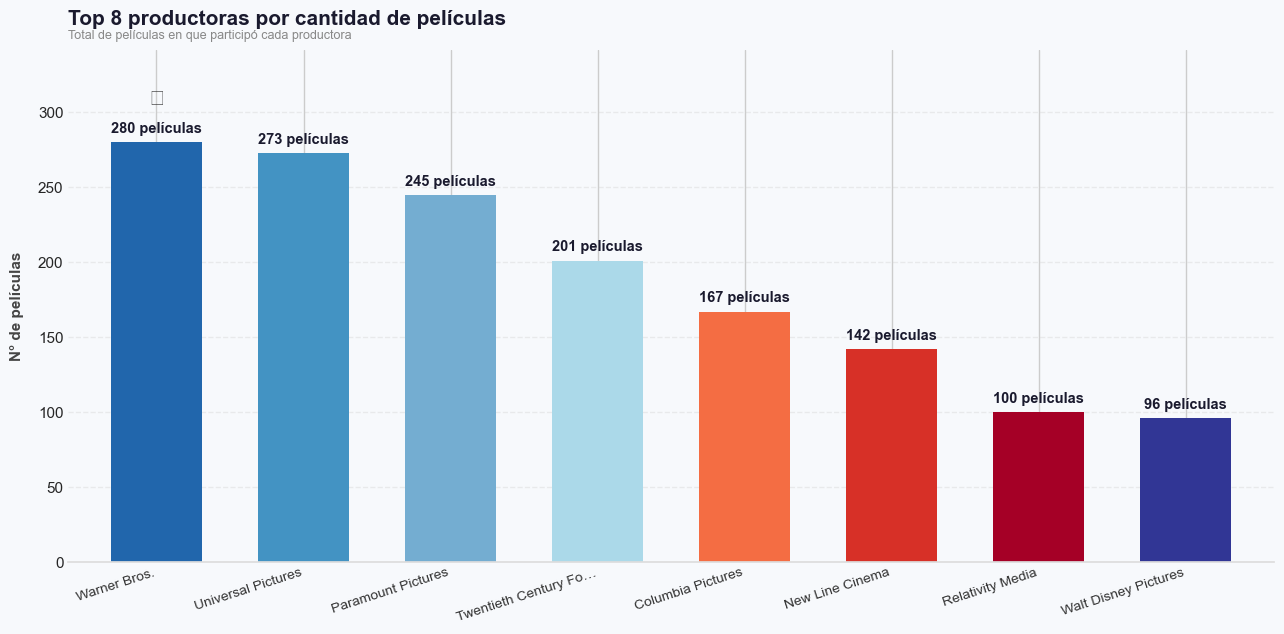

In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import ast

def extraer_companias(valor):
    if pd.isna(valor): return []
    try:
        lista = ast.literal_eval(valor)
        return [d['name'] for d in lista if isinstance(d, dict) and 'name' in d]
    except:
        return [c.strip() for c in str(valor).split(',') if c.strip()]

df_exp = df1[['production_companies']].copy()
df_exp['production_companies'] = df_exp['production_companies'].apply(extraer_companias)
df_exp = df_exp.explode('production_companies')
df_exp = df_exp[df_exp['production_companies'].notna() & (df_exp['production_companies'] != '')]

top8 = (df_exp.groupby('production_companies')
              .size()
              .sort_values(ascending=False)
              .head(8))

etiquetas = top8.index.tolist()
colores   = ['#2166ac','#4393c3','#74add1','#abd9e9',
             '#f46d43','#d73027','#a50026','#313695']

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

x    = np.arange(len(etiquetas))
bars = ax.bar(x, top8.values, width=0.62, color=colores, zorder=2, linewidth=0)

for bar, val in zip(bars, top8.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + top8.max() * 0.015,
            f'{val} películas',
            ha='center', va='bottom',
            fontsize=10.5, fontweight='bold', color='#1a1a2e')

ax.annotate('🏆', xy=(x[0], top8.values[0]),
            xytext=(x[0], top8.values[0] + top8.max() * 0.09),
            ha='center', fontsize=16)

ax.set_xticks(x)
ax.set_xticklabels([e if len(e) <= 22 else e[:20] + '…' for e in etiquetas],
                   fontsize=10, rotation=18, ha='right', color='#333333')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v)}'))
ax.set_ylabel('N° de películas', fontsize=11, fontweight='bold',
              labelpad=10, color='#444444')
ax.set_ylim(0, top8.max() * 1.22)
ax.set_xlim(-0.6, len(etiquetas) - 0.4)

ax.set_title('Top 8 productoras por cantidad de películas',
             fontsize=15, fontweight='bold', pad=18, loc='left', color='#1a1a2e')
ax.text(0, 1.015,
        'Total de películas en que participó cada productora',
        transform=ax.transAxes, fontsize=9, color='#888888', va='bottom')

ax.grid(axis='y', linestyle='--', alpha=0.35, zorder=0)
ax.tick_params(axis='both', length=0)
for spine in ['top', 'right', 'left']: ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#dddddd')

plt.tight_layout()
plt.show()

In [47]:
columnas_utiles=['log_revenue',"log_budget_scaled",
       'is_business_day_release', 'genre_Drama', 'genre_Horror',
       'genre_Comedy', 'genre_Action', 'genre_Crime', 'genre_Fantasy',
       'genre_Romance', 'genre_Adventure', 'genre_Family', 'genre_Other','big_studio','log_popularity_scaled','vote_average','main_language_english',"release_season",'antiguedad']

data=df1[columnas_utiles]

## matriz de correlacion

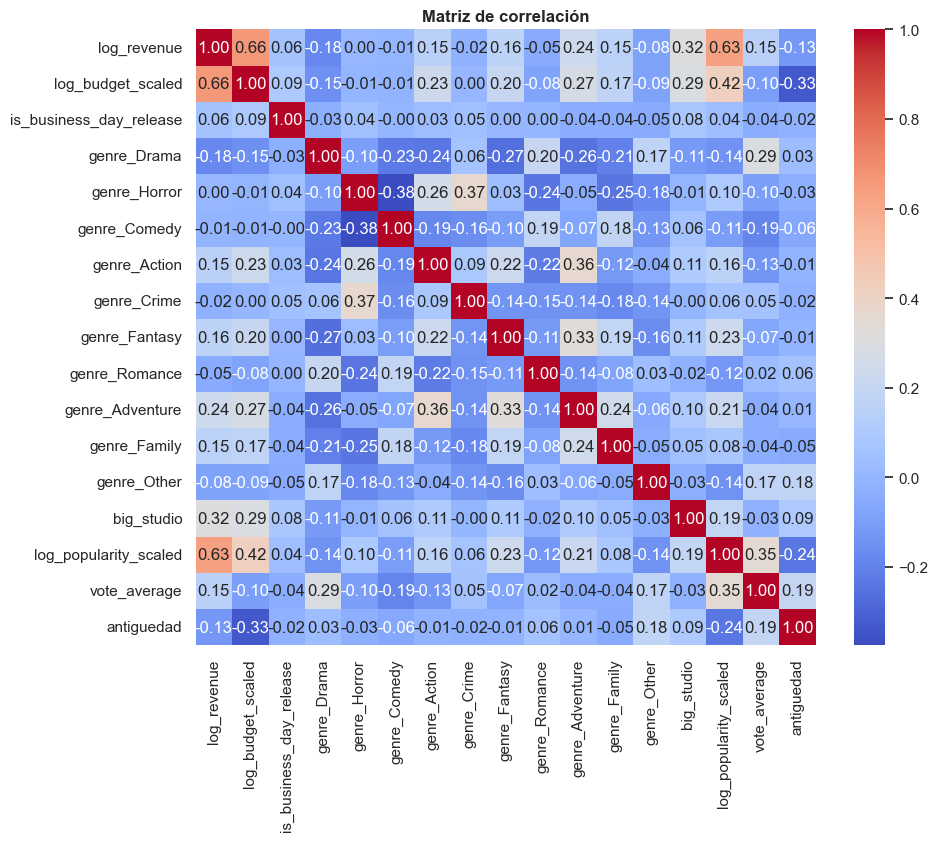

In [48]:


def heatmap_corr(df):
    corr = df.select_dtypes(include='number').corr()
    
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    
    plt.title('Matriz de correlación')
    plt.show()
heatmap_corr(data)    

## graficos de dispersion

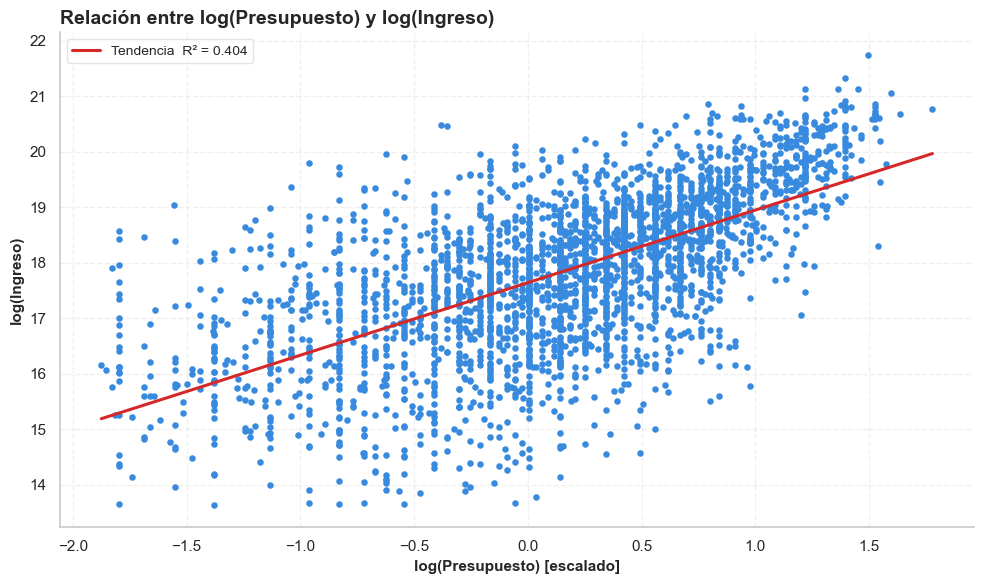

In [49]:
from scipy import stats

scatter_df = df1[['log_budget_scaled', 'log_revenue']].dropna()
for col in ['log_budget_scaled', 'log_revenue']:
    q1, q3 = scatter_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    scatter_df = scatter_df[(scatter_df[col] >= q1 - 1.5*iqr) & (scatter_df[col] <= q3 + 1.5*iqr)]

x, y = scatter_df['log_budget_scaled'].values, scatter_df['log_revenue'].values
slope, intercept, r_val, *_ = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, color='#378ADD', s=22, alpha=1, linewidths=0, zorder=2)
ax.plot(x_line, intercept + slope * x_line, color='#d62828', linewidth=2.2,
        label=f'Tendencia  R² = {r_val**2:.3f}', zorder=3)

ax.set_xlabel('log(Presupuesto) [escalado]', fontsize=11, fontweight='bold')
ax.set_ylabel('log(Ingreso)', fontsize=11, fontweight='bold')
ax.set_title('Relación entre log(Presupuesto) y log(Ingreso)',
             fontsize=14, fontweight='bold', loc='left')
ax.legend(fontsize=10, frameon=True, edgecolor='#dddddd')
ax.grid(linestyle='--', alpha=0.3)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.show()

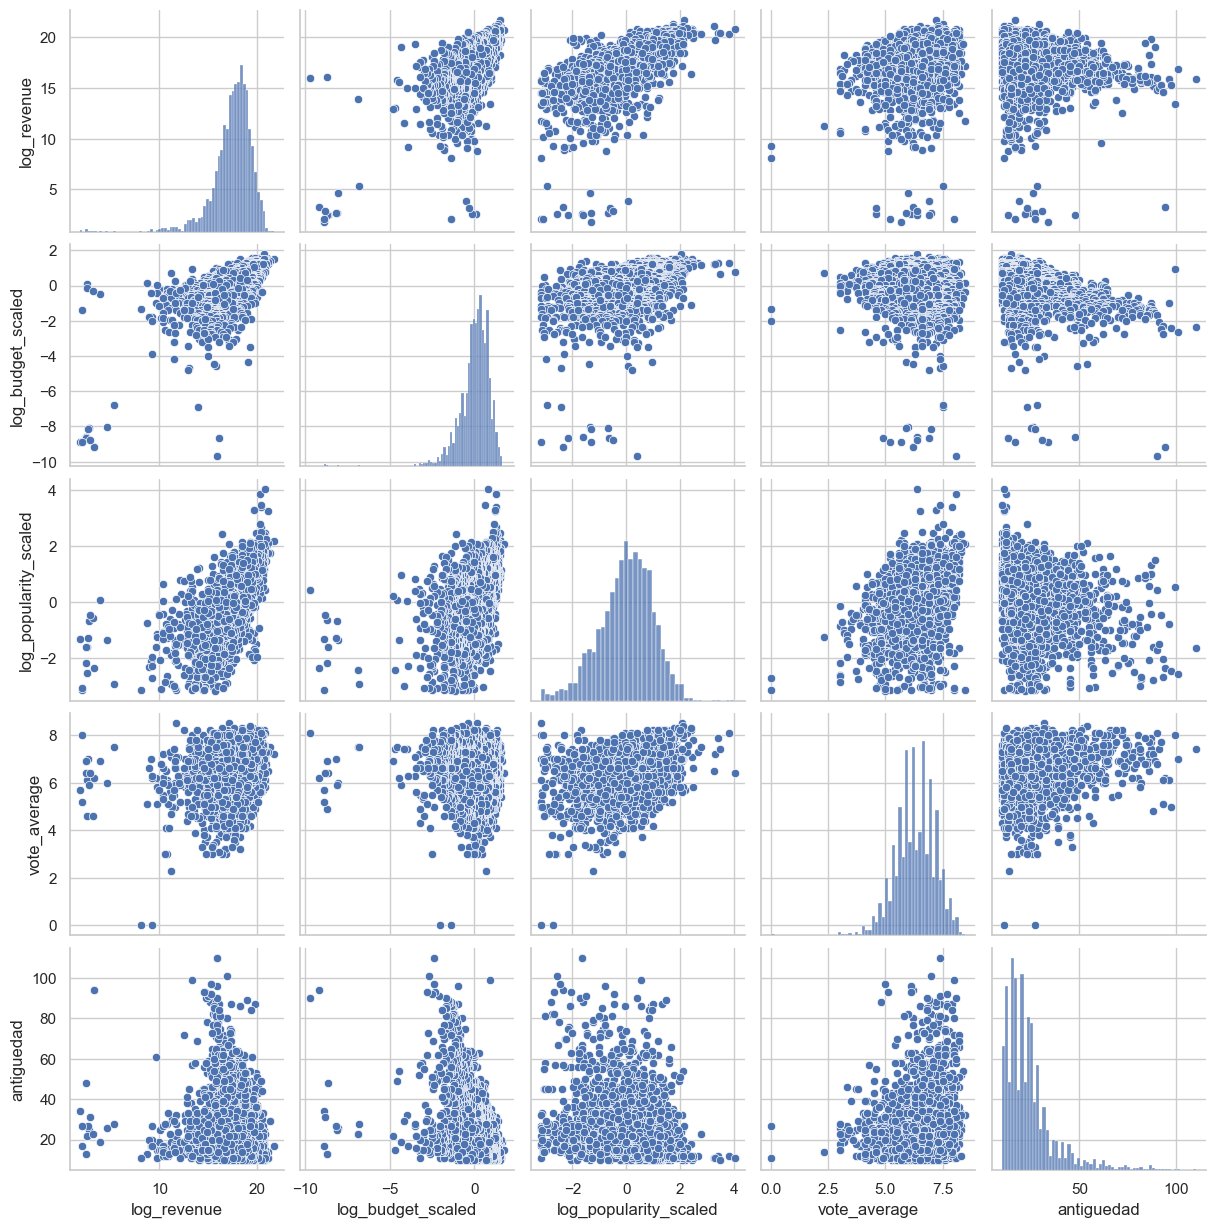

In [50]:
sns.pairplot(data.select_dtypes(include='number').loc[:, data.select_dtypes(include='number').nunique() > 2])

# Regresion multivariada

In [51]:
data.columns

Index(['log_revenue', 'log_budget_scaled', 'is_business_day_release',
       'genre_Drama', 'genre_Horror', 'genre_Comedy', 'genre_Action',
       'genre_Crime', 'genre_Fantasy', 'genre_Romance', 'genre_Adventure',
       'genre_Family', 'genre_Other', 'big_studio', 'log_popularity_scaled',
       'vote_average', 'main_language_english', 'release_season',
       'antiguedad'],
      dtype='object')

In [52]:
data["interaccion_1"]=data['antiguedad']*data["genre_Drama"]
data["interaccion_2"]=data['antiguedad']*data["genre_Action"] #0.135
data["interaccion_3"]=data['antiguedad']*data["genre_Crime"]  #0.049
data["interaccion_4"]=data['antiguedad']*data["genre_Fantasy"] #0.614
data["interaccion_5"]=data['antiguedad']*data["genre_Romance"] #
data["interaccion_6"]=data['antiguedad']*data["genre_Adventure"]
data["interaccion_7"]=data['antiguedad']*data["genre_Family"] #0.429
data["interaccion_9"]=data['antiguedad']*data["genre_Other"]  #0.915


In [53]:
data.columns

Index(['log_revenue', 'log_budget_scaled', 'is_business_day_release',
       'genre_Drama', 'genre_Horror', 'genre_Comedy', 'genre_Action',
       'genre_Crime', 'genre_Fantasy', 'genre_Romance', 'genre_Adventure',
       'genre_Family', 'genre_Other', 'big_studio', 'log_popularity_scaled',
       'vote_average', 'main_language_english', 'release_season', 'antiguedad',
       'interaccion_1', 'interaccion_2', 'interaccion_3', 'interaccion_4',
       'interaccion_5', 'interaccion_6', 'interaccion_7', 'interaccion_9'],
      dtype='object')

In [54]:
df1["revenue"].mean()

121279998.84355637

## resultado ols

In [55]:
data['log_budget_scaled_sq'] = data['log_budget_scaled']**2
resultado4 = smf.ols('log_revenue ~log_popularity_scaled+vote_average+log_budget_scaled+log_budget_scaled_sq+big_studio+genre_Drama+genre_Horror+genre_Comedy+genre_Action+genre_Crime+genre_Fantasy+genre_Romance+genre_Adventure+genre_Family+C(release_season)+antiguedad' , data=data).fit() 
print(resultado4.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     299.1
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:32:19   Log-Likelihood:                -5351.5
No. Observations:                3228   AIC:                         1.074e+04
Df Residuals:                    3209   BIC:                         1.086e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

## test estadisticos

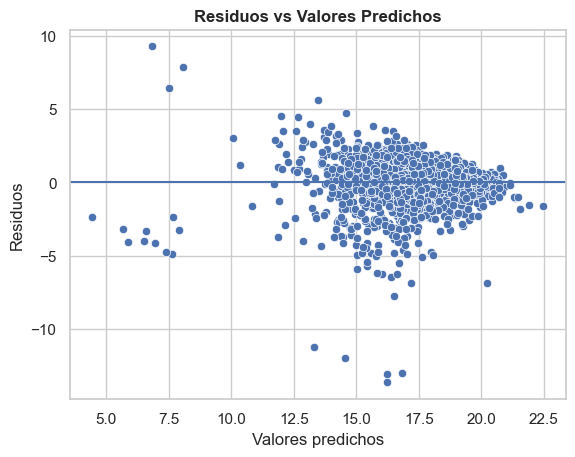

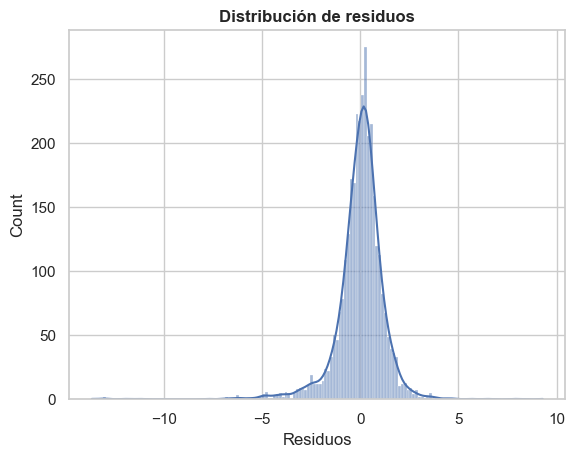

<Figure size 640x480 with 0 Axes>

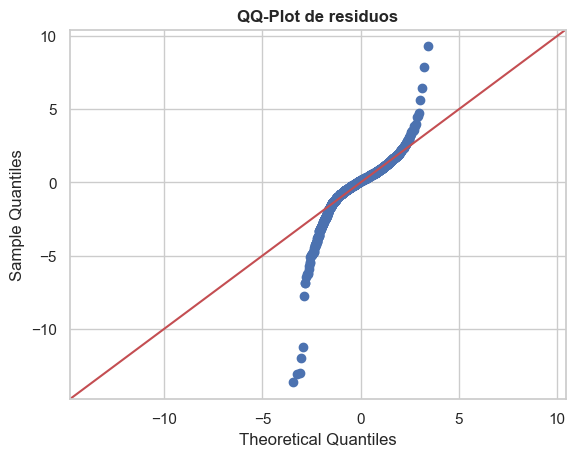

In [56]:
# Predicciones (IMPORTANTE: usar el mismo DataFrame)
y_pred = resultado4.predict(data)

# Residuos
residuos = data['log_revenue'] - y_pred

# -------------------------------
# 1. Residuos vs valores predichos
# -------------------------------
plt.figure()
sns.scatterplot(x=y_pred, y=residuos)
plt.axhline(0)
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores Predichos")
plt.show()

# -------------------------------
# 2. Histograma de residuos
# -------------------------------
plt.figure()
sns.histplot(residuos, kde=True)
plt.xlabel("Residuos")
plt.title("Distribución de residuos")
plt.show()

# -------------------------------
# 3. QQ-plot (normalidad)
# -------------------------------
import statsmodels.api as sm

plt.figure()
sm.qqplot(residuos, line='45')
plt.title("QQ-Plot de residuos")
plt.show()

## interpretacion de coeficientes

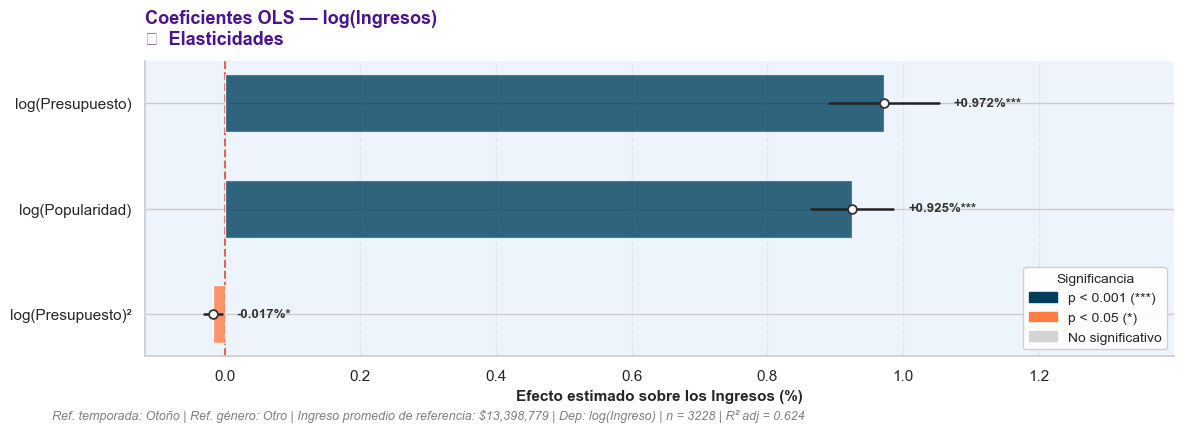

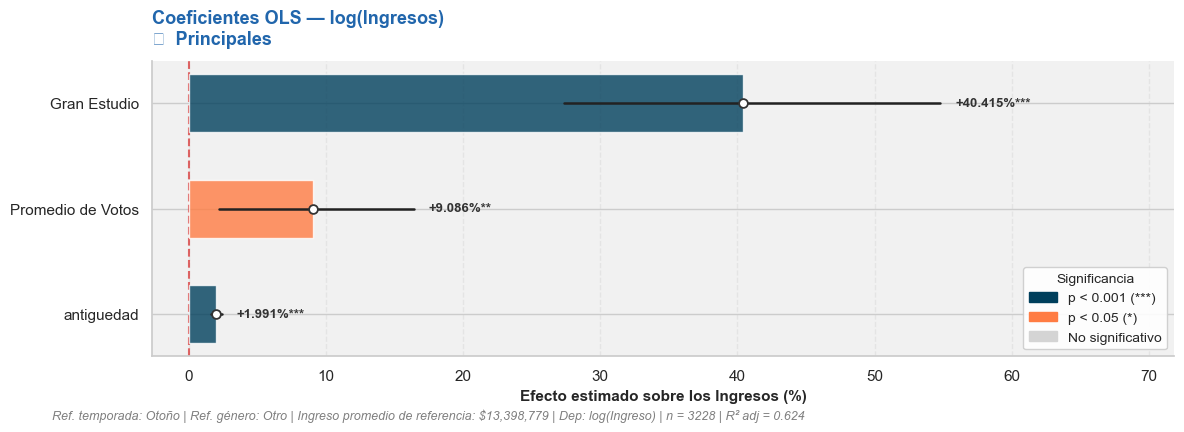

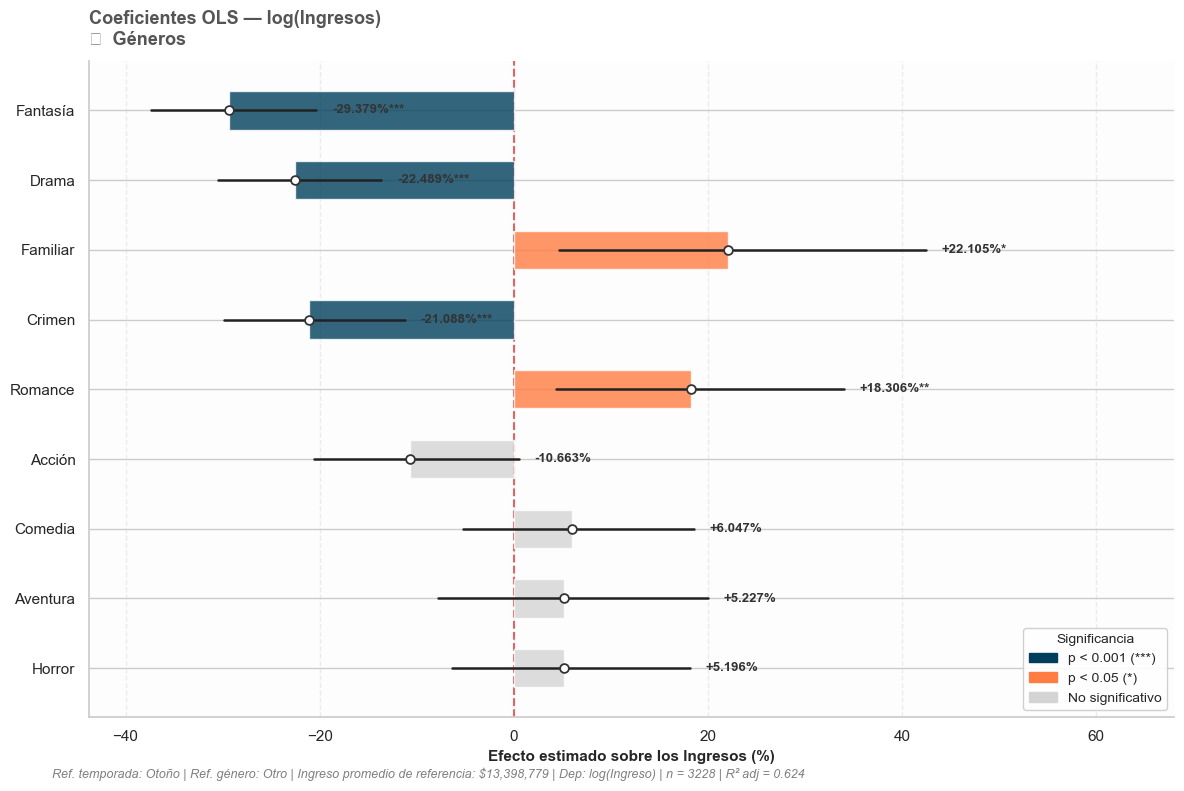

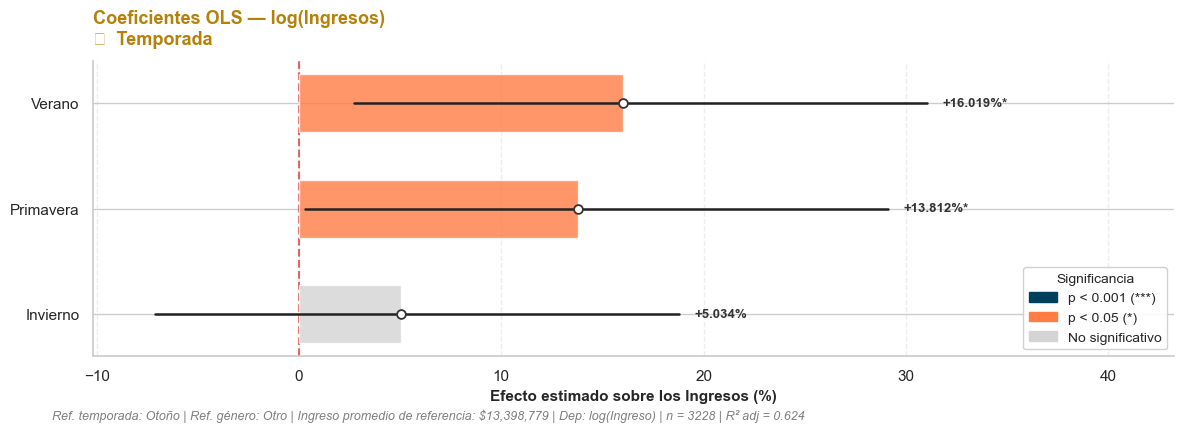

In [57]:
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from matplotlib.transforms import blended_transform_factory

def forest_plot_ols_pro(modelo, titulo="Análisis de Coeficientes OLS", referencia_season="Otoño"):

    # 1. Extracción
    constante  = 'Intercept' if 'Intercept' in modelo.params.index else 'const'
    const_val  = modelo.params[constante]
    ingreso_ref = np.exp(const_val)

    coef = modelo.params.drop(constante)
    ci   = modelo.conf_int().drop(constante)
    pval = modelo.pvalues.drop(constante)

    nombres_limpios = {
        'log_popularity_scaled':  'log(Popularidad)',
        'vote_average':           'Promedio de Votos',
        'interaccion_1':          'Antigüedad × Drama',
        'interaccion_5':          'Antigüedad × Romance',
        'interaccion_6':          'Antigüedad × Aventura',
        'log_budget_scaled':      'log(Presupuesto)',
        'log_budget_scaled_sq':   'log(Presupuesto)²',
        'genre_Drama':            'Drama',
        'genre_Horror':           'Horror',
        'genre_Comedy':           'Comedia',
        'genre_Action':           'Acción',
        'genre_Crime':            'Crimen',
        'genre_Fantasy':          'Fantasía',
        'genre_Romance':          'Romance',
        'genre_Adventure':        'Aventura',
        'genre_Family':           'Familiar',
        'genre_Other':            'Otro',
        'big_studio':             'Gran Estudio',
    }

    shade_colors = {
        'Principales':   '#f1f1f1',
        'Géneros':       '#fdfdfd',
        'Temporada':     '#ffffff',
        'Interacciones': '#f0faf0',
        'Elasticidades':           '#eef4fb',   # ✅ nuevo grupo
    }

    header_colors = {
        'Principales':   '#2166ac',
        'Géneros':       '#555555',
        'Temporada':     '#b5810a',
        'Interacciones': '#2e8b57',
        'Elasticidades':           '#4a148c',   # ✅ morado para distinguirlo
    }

    def get_category(n):
        if 'log' in n.lower():        return 'Elasticidades'
        if 'release_season' in n:     return 'Temporada'
        if 'genre_' in n:             return 'Géneros'
        if 'interaccion' in n:        return 'Interacciones'
        return 'Principales'

    def get_label(n):
        if 'release_season' in n:
            season_en = n.split('[T.')[1].rstrip(']') if '[T.' in n else n
            traducciones_season = {
                'Spring': 'Primavera',
                'Summer': 'Verano',
                'Winter': 'Invierno',
                'Fall':   'Otoño',
            }
            return traducciones_season.get(season_en, season_en)
        return nombres_limpios.get(n, n)

    def efecto(v, n):
        return v  if 'log' in n.lower() else (np.exp(v) - 1) * 100

    def get_color(p):
        if p < 0.001:  return '#003f5c'
        elif p < 0.05: return '#ff7c43'
        else:          return '#d4d4d4'

    def get_sig(p):
        if p < 0.001:  return '***'
        elif p < 0.01: return '**'
        elif p < 0.05: return '*'
        else:          return ''

    # 2. Construir DataFrame completo
    records = []
    for n in coef.index:
        ef    = efecto(coef[n], n)
        lo_ef = efecto(ci.loc[n, 0], n)
        hi_ef = efecto(ci.loc[n, 1], n)
        lo_ef, hi_ef = min(lo_ef, hi_ef), max(lo_ef, hi_ef)
        records.append({
            'var_name': n,
            'label':    get_label(n),
            'category': get_category(n),
            'efecto':   ef,
            'lo_ef':    lo_ef,
            'hi_ef':    hi_ef,
            'pval':     pval[n],
            'color':    get_color(pval[n]),
            'abs_ef':   abs(ef),
        })

    df_all = pd.DataFrame(records)

    # Leyenda común
    elementos_leyenda = [
        mpatches.Patch(color='#003f5c', label='p < 0.001 (***)'),
        mpatches.Patch(color='#ff7c43', label='p < 0.05 (*)'),
        mpatches.Patch(color='#d4d4d4', label='No significativo'),
    ]

    # Nota al pie común
    info = (f"Ref. temporada: {referencia_season} | "
            f"Ref. género: Otro | "
            f"Ingreso promedio de referencia: ${ingreso_ref:,.0f} | "
            f"Dep: log(Ingreso) | "
            f"n = {int(modelo.nobs)} | "
            f"R² adj = {modelo.rsquared_adj:.3f}")

    # 3. Un gráfico por categoría (Log va primero)
    cat_order = ['Elasticidades', 'Principales', 'Géneros', 'Temporada', 'Interacciones']

    for cat in cat_order:
        df = (df_all[df_all['category'] == cat]
              .sort_values('abs_ef', ascending=True)
              .reset_index(drop=True))

        if df.empty:
            continue

        fig_h   = max(len(df) * 0.6 + 2.5, 4)
        fig, ax = plt.subplots(figsize=(12, fig_h))
        ax.set_facecolor(shade_colors[cat])

        all_hi     = df['hi_ef'].max()
        all_lo     = df['lo_ef'].min()
        data_range = all_hi - all_lo if all_hi != all_lo else 1

        # 4. Barras + IC + punto + etiqueta
        for _, row in df.iterrows():
            ax.barh(row.name, row['efecto'], color=row['color'],
                    alpha=0.80, height=0.55, zorder=2)

            ax.plot([row['lo_ef'], row['hi_ef']], [row.name, row.name],
                    color='#222222', linewidth=1.8, zorder=3, solid_capstyle='round')

            ax.scatter(row['efecto'], row.name, color='white', s=40,
                       zorder=4, edgecolors='#333333', linewidth=1.3)

            x_label = max(row['hi_ef'], row['efecto']) + data_range * 0.02
            ax.text(x_label, row.name,
                    f'{row["efecto"]:+.3f}%{get_sig(row["pval"])}',
                    va='center', ha='left', fontsize=9.5,
                    fontweight='bold', color='#333333', zorder=5)

        # 5. Línea de referencia en 0
        ax.axvline(0, color='#d62828', linestyle='--',
                   linewidth=1.5, alpha=0.7, zorder=1)

        # 6. Ejes y estética
        ax.set_yticks(df.index)
        ax.set_yticklabels(df['label'], fontsize=11)
        ax.set_xlim(all_lo - data_range * 0.08,
                    all_hi + data_range * 0.32)
        ax.set_xlabel('Efecto estimado sobre los Ingresos (%)',
                      fontsize=11, fontweight='semibold')
        ax.set_title(f'{titulo}\n▸  {cat}',
                     fontsize=13, fontweight='bold', pad=12,
                     loc='left', color=header_colors[cat])

        ax.grid(axis='x', linestyle='--', alpha=0.35, zorder=0)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

        # 7. Leyenda
        ax.legend(handles=elementos_leyenda, frameon=True,
                  framealpha=0.9, edgecolor='#cccccc',
                  loc='lower right', fontsize=10,
                  title='Significancia', title_fontsize=10)

        # 8. Nota al pie en todos los gráficos
        plt.figtext(0.05, 0.005, info, fontsize=9, color='gray', style='italic')

        plt.tight_layout()
        plt.show()


# --- Llamada ---
forest_plot_ols_pro(
    resultado4,
    titulo="Coeficientes OLS — log(Ingresos)",
    referencia_season="Otoño"
)

# informe de resultados

## contexto del mercado
La industria cinematográfica, durante la última década, ha experimentado una transformación significativa impulsada por avances tecnológicos. Estos han favorecido el auge de géneros como la ciencia ficción, la acción y la fantasía, al mismo tiempo que han contribuido al declive relativo de géneros tradicionales como el drama, la comedia y el romance.

Al analizar cuáles son los géneros más populares en la última década, se observa lo siguiente:

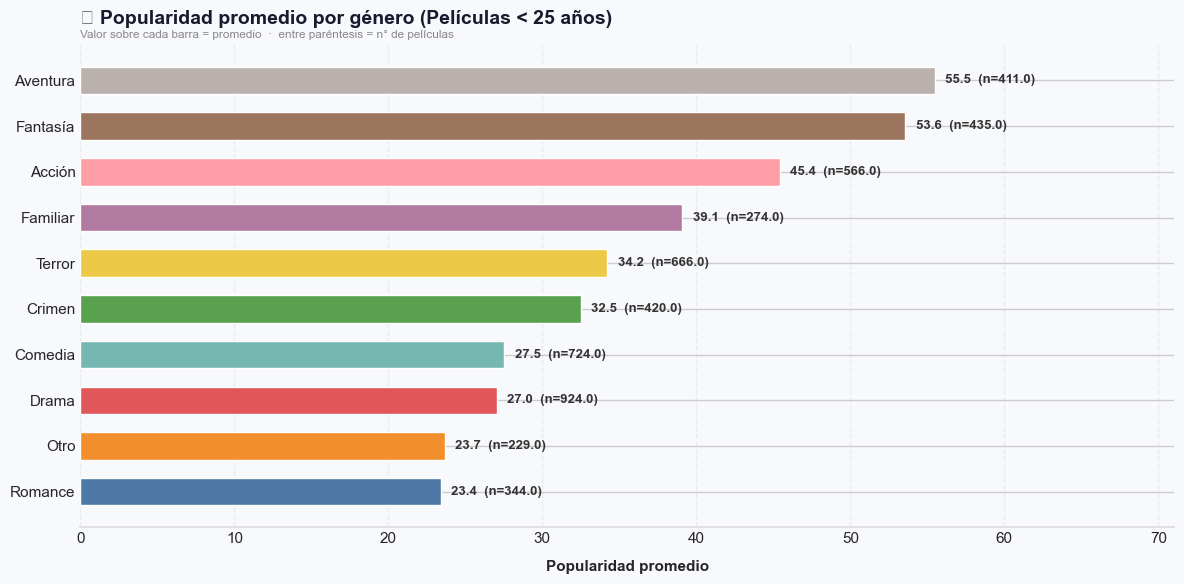



Se puede apreciar que los géneros capaces de aprovechar mejor los avances tecnológicos tienden a ser los más populares. Sin embargo, estos cambios no solo han modificado las preferencias del público en términos de género, sino que también han impactado de manera relevante en la estructura del mercado cinematográfico.

Las empresas que han logrado adaptarse a estas transformaciones han sido significativamente favorecidas, dando lugar a una estructura de mercado similar a un oligopolio. En este contexto, un número reducido de productoras concentra una proporción importante de los ingresos totales y de la podruccion, tal como se ilustra a continuación:


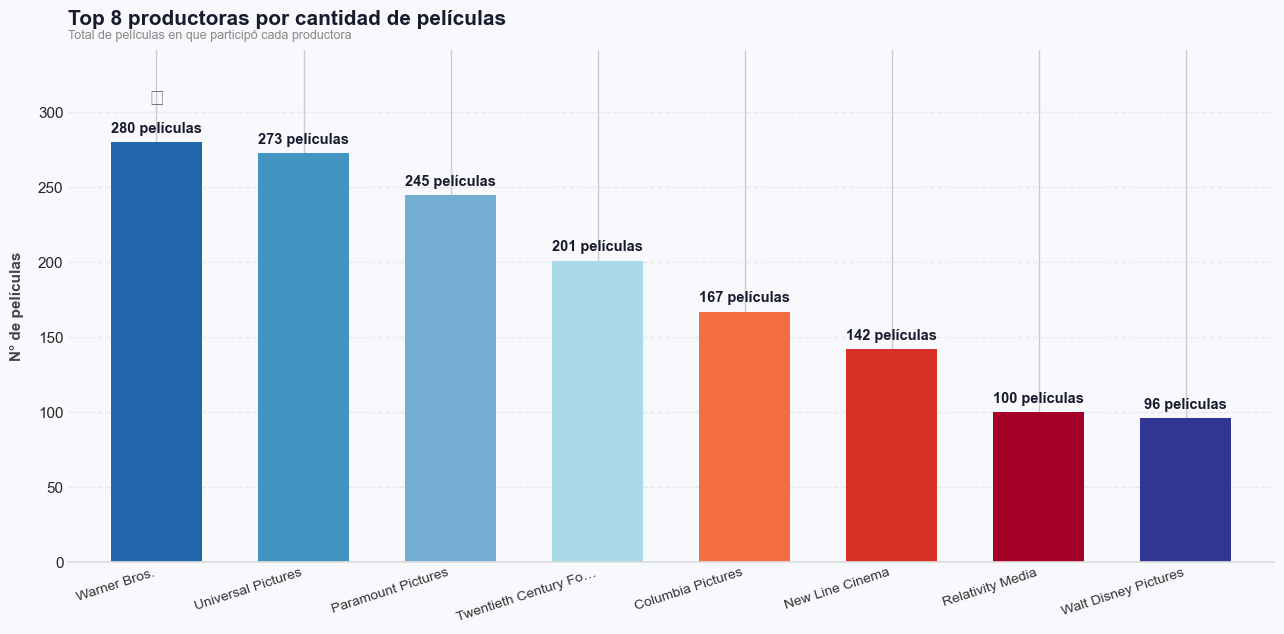

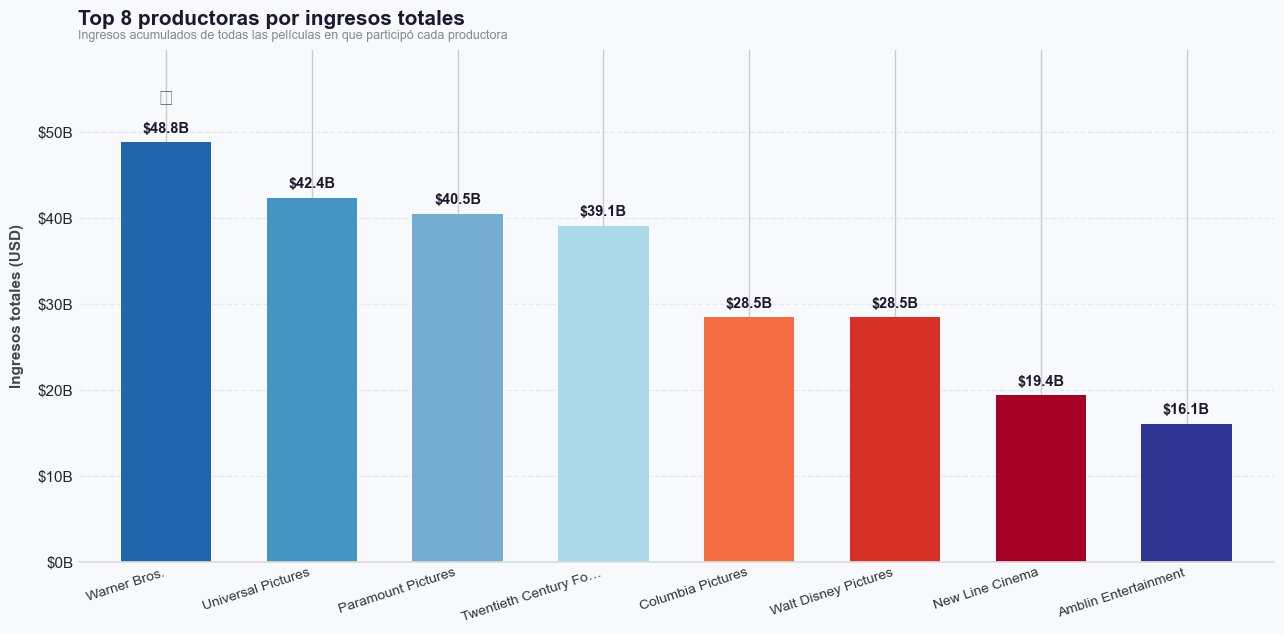

Se observan diferencias considerables tanto en la cantidad de películas producidas como en ingresos de las tres principales productoras y el resto de las empresas. Esto sugiere que el mercado cinematográfico está dominado por un grupo reducido de grandes estudios con alta participación, lo que genera importantes barreras de entrada para productoras emergentes.

## características de las variables en la base de datos 

En el dataset entregado se incluían múltiples variables que describen distintos aspectos de las películas, tales como la fecha de lanzamiento, el nombre, la productora, el género y la duración, entre otros.

En este contexto, las variables pueden clasificarse en dos grandes grupos: variables categóricas y variables continuas.

Con el objetivo de evitar trabajo innecesario y mejorar la calidad del análisis, se optó por descartar variables que no tuvieran una relación directa con el desempeño y los ingresos de una película. El criterio utilizado fue principalmente lógico: por ejemplo, aunque un nombre llamativo puede atraer cierta atención inicial, es poco probable que tenga un impacto significativo en los ingresos. De manera similar, la duración de la película no debería afectar sustancialmente la cantidad de espectadores.

Asimismo, se evitó incluir variables colineales, como el total de votos junto con el promedio de votos, así como variables que resultaron no significativas en el modelo de regresión, por ejemplo, si el día de estreno correspondía a un día laborable.

Bajo este contexto, se presenta a continuación el conjunto de variables utilizadas en la estimación del modelo de demanda:


| Variable                  | Tipo        | Descripción                                                                                  |
|--------------------------|-------------|----------------------------------------------------------------------------------------------|
| log(presupuesto)         | Continua    | Logaritmo del presupuesto de la película, utilizado para reducir la dispersión de los datos. |
| log(popularidad)         | Continua    | Logaritmo de la popularidad de la película, que captura su nivel de interés o visibilidad.   |
| Gran estudio             | Binaria     | Indica si la película fue producida por un estudio grande (1: sí, 0: en caso contrario).     |
| Promedio de votos        | Continua    | Puntuación promedio otorgada por los usuarios (escala de 0 a 10).                            |
| Antigüedad               | Continua    | Años transcurridos desde el estreno de la película hasta la fecha de análisis.               |
| log(presupuesto)^2       | Continua    | Término cuadrático del logaritmo del presupuesto, usado para capturar efectos no lineales.   |
| log(ingreso)             | Continua    | Logaritmo de los ingresos de la película; variable objetivo del modelo.                      |
| Género                   | Categórica  | Variable que indica hasta 3 generos cinematograficos de la pelicula                          |
| Temporada                | Categórica  | Estación del año en la que se estrenó la película (invierno, primavera, verano, otoño).      |

## los ajustes realizados a la base de datos para la estimación (e.g. limpieza de datos, creación de variables)

Se realizaron tres ajustes fundamentales en la base de datos: limpieza de outliers y valores nulos, codificación de variables categóricas y transformación de variables continuas.

Para la detección de outliers, se analizaron las variables continuas, encontrándose que no existía una cantidad significativa de valores atípicos (el máximo fue cercano a 500 en una base de aproximadamente 4000 observaciones), por lo que no fue necesario aplicar métodos agresivos de depuración en este aspecto.

Posteriormente, se evaluó la presencia de valores nulos en las variables revenue y budget, dado que son fundamentales para el análisis. Se encontró que cerca del 30% de los datos en revenue eran nulos, por lo que se decidió eliminarlos, ya que no aportan información relevante y podrían deteriorar el ajuste del modelo. El mismo procedimiento se aplicó a la variable budget.

Luego, se aplicó codificación one-hot encoding a variables categóricas como el género. Además, la variable de fecha se descompuso en día, mes y año, lo que permitió construir nuevas variables derivadas, como la antigüedad de la película y la temporada de estreno.

Finalmente, se aplicaron transformaciones logarítmicas a variables con distribuciones altamente asimétricas, como popularidad, presupuesto e ingresos, con el objetivo de reducir la dispersión, estabilizar la varianza y mejorar el ajuste del modelo.

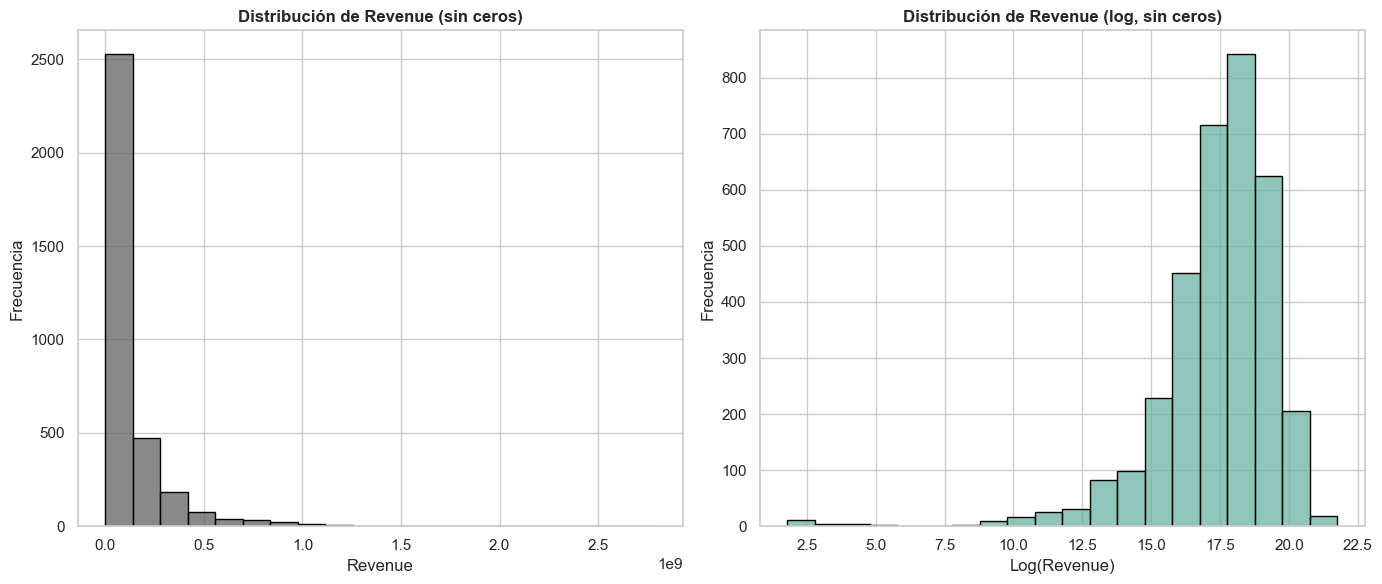
## el método de análisis

Se realizó un análisis exploratorio inicial para estudiar la distribución de variables como ingresos, popularidad e inversión, mediante histogramas y diagramas de caja.

Posteriormente, se analizó la relación entre variables a través de gráficos de barras considerando dimensiones como género, temporada y ROI, con el objetivo de identificar patrones relevantes en los datos.

Adicionalmente, se utilizaron gráficos de dispersión y matrices de correlación para evaluar la relación conjunta entre variables y detectar posibles dependencias o problemas de multicolinealidad.

Finalmente, se estimó un modelo log-lineal utilizando el método de mínimos cuadrados ordinarios, analizando los coeficientes obtenidos para interpretar cómo las distintas variables influyen en los ingresos de una película.

## los resultados encontrados
Los principales resultados se dividen en distintos grupos de variables, los cuales se presentan a continuación mediante cuatro gráficos:

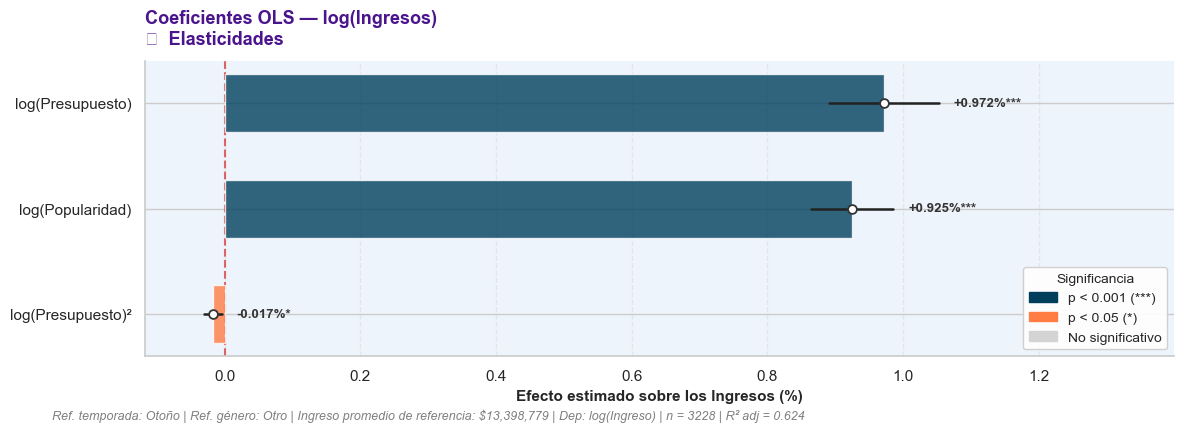
El gráfico anterior representa el impacto de cada variable sobre los ingresos. En particular, para las variables en escala logarítmica, los coeficientes pueden interpretarse como elasticidades; es decir, ante un aumento del 1% en X, se produce un cambio porcentual de β% en Y. Por ejemplo, a partir del primer gráfico se observa que un aumento del 1% en el presupuesto genera un incremento de aproximadamente 0,972% en los ingresos. Además, se identifica un término cuadrático negativo asociado al presupuesto, lo que indica la presencia de rendimientos decrecientes: el impacto de la inversión sobre los ingresos disminuye a medida que esta aumenta.


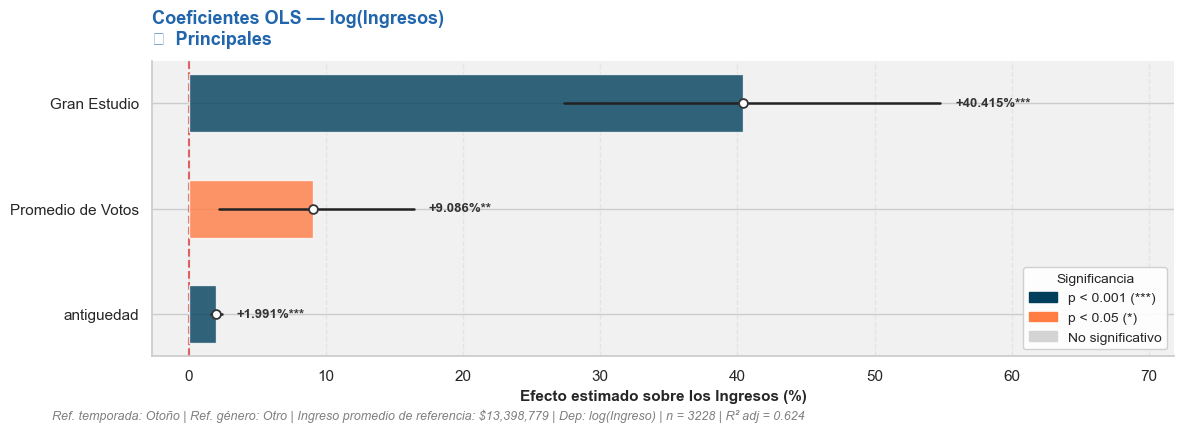

Por otro lado, las variables lineales del modelo permiten una interpretación distinta. En este caso, un aumento de una unidad en X se traduce en un cambio aproximado de β×100% en Y. Por ejemplo, en el caso de la variable antigüedad, se puede interpretar que por cada año adicional desde el estreno de la película, sus ingresos aumentan en aproximadamente un 1,99%, lo cual sugiere un efecto relativamente bajo en el tiempo.

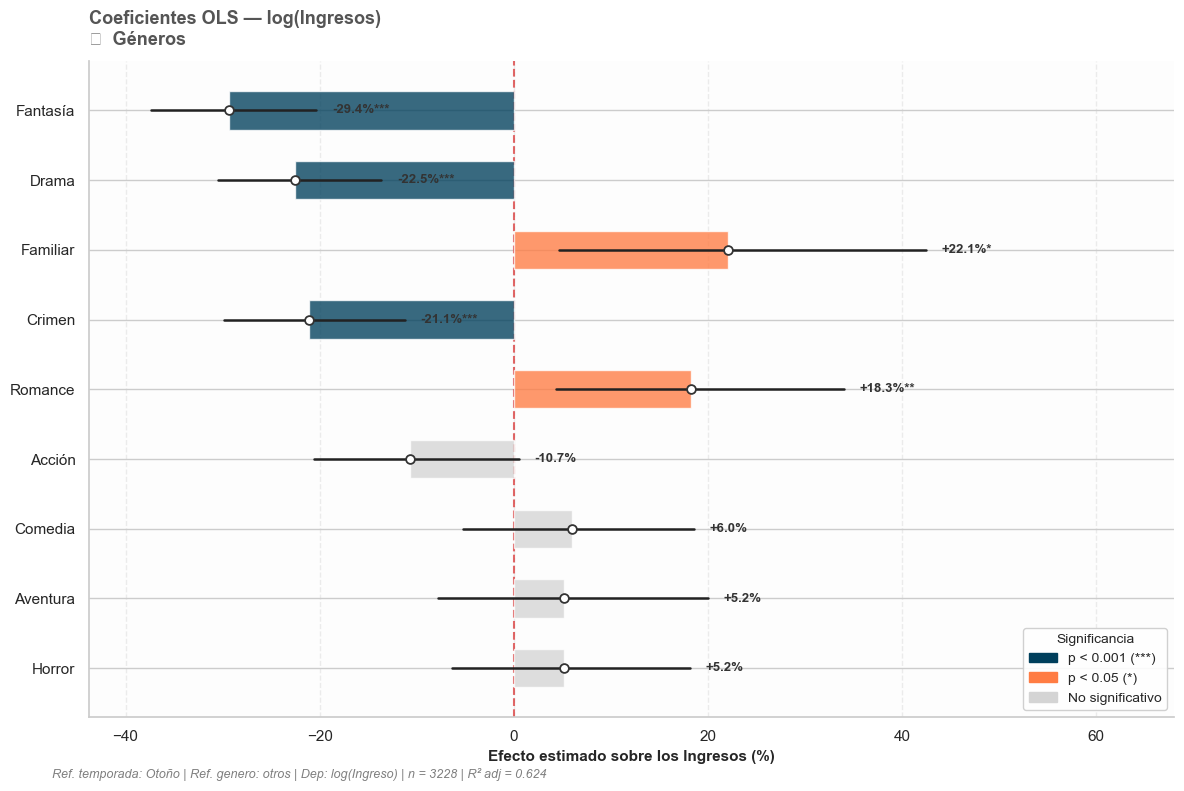
 
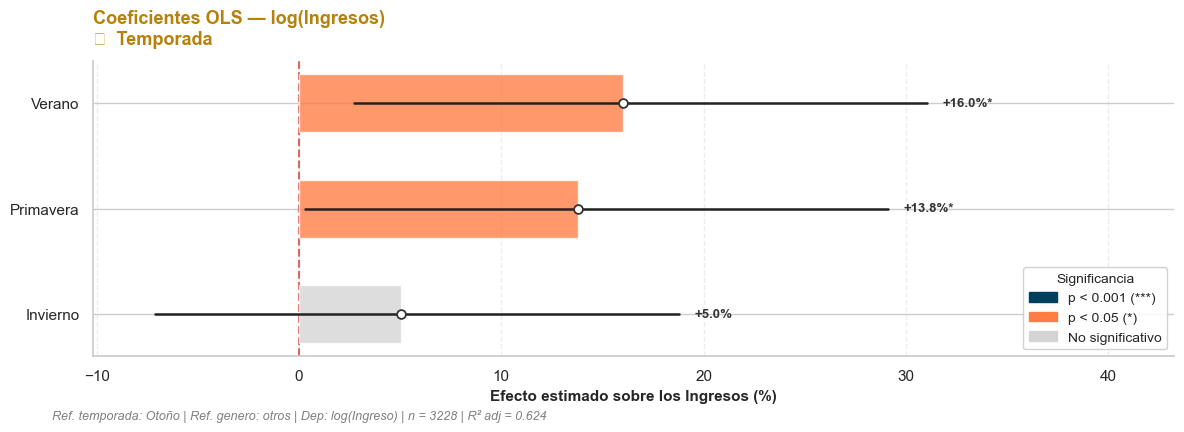

La interpretación de las variables categóricas es análoga a la de las variables lineales. Por ejemplo, a partir del gráfico de géneros, se puede inferir que una película del género romance incrementa su recaudación en aproximadamente un 22% en comparación con la categoría base. De manera similar, el gráfico de temporadas muestra que estrenar una película en verano puede generar cerca de un 16% más de ingresos en comparación con otoño, mientras que no se observan diferencias estadísticamente significativas entre invierno y otoño.

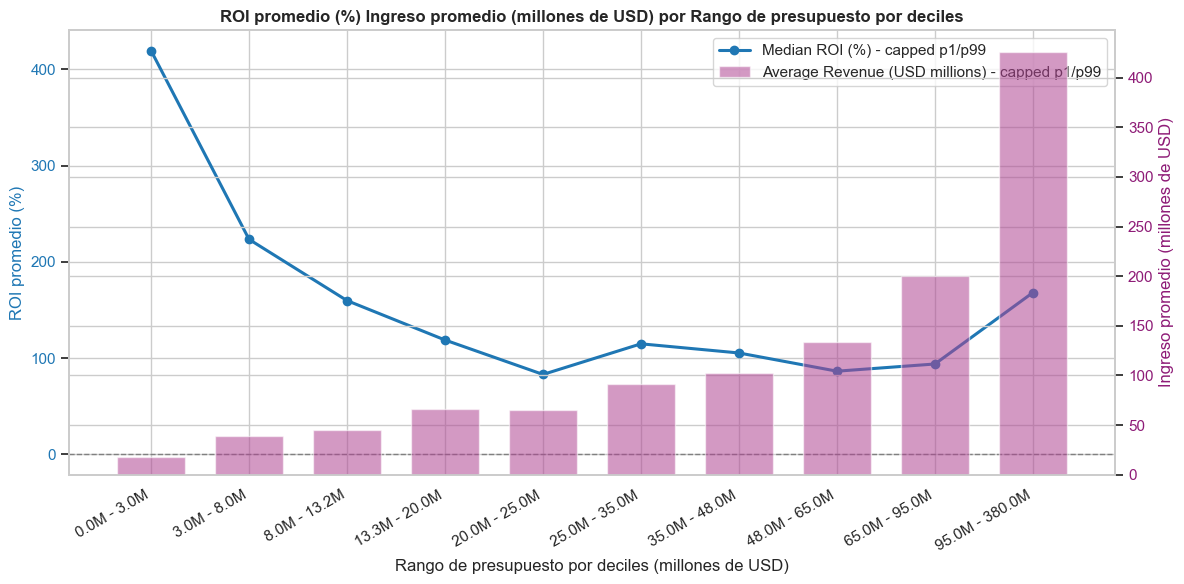

Adicionalmente, para respaldar el hallazgo de rendimientos decrecientes de la inversión, se construyó un gráfico de ROI por deciles de inversión. En este se observa que el retorno tiende a disminuir a medida que aumenta la inversión, con excepción del último decil. Este último probablemente representa megaproducciones, en las cuales el éxito en taquilla permite obtener retornos superiores al promedio. Estas producciones suelen estar financiadas por las principales empresas del mercado, que son las únicas capaces de asumir ese nivel de inversión.

## recomendaciones que se pueden realizar respecto del mercado.

En base a los resultados anteriormente presentados, es posible extraer una serie de conclusiones que pueden traducirse en recomendaciones para empresas del sector creativo. A continuación, se presentan las más relevantes:

-Debido a las diferencias significativas en los ingresos según la temporada de estreno, se recomienda lanzar películas en verano o primavera, ya que estas estaciones presentan un mayor impacto positivo en la recaudación. Por el contrario, se sugiere evitar estrenos en invierno u otoño, donde el efecto sobre los ingresos es considerablemente menor.

-A partir del análisis de los coeficientes asociados al género, se recomienda evitar películas de fantasía si el objetivo es maximizar ingresos. En su lugar, sería preferible priorizar géneros como romance o aventura, que presentan un mejor desempeño en términos de recaudación.

-Los resultados respaldan que el mercado cinematográfico presenta una alta concentración de ingresos en grandes productoras. En particular, se encontró que las películas producidas por estudios de renombre generan, en promedio, un 40% más de ingresos que aquellas producidas por empresas pequeñas (con menos de 90 películas producidas).

-Se observa que los votos tienen un bajo impacto directo en los ingresos y, además, presentan una alta correlación con la popularidad. Esto sugiere que las votaciones funcionan más como un indicador de visibilidad o interés del público que como un determinante del éxito en taquilla.

-Se recomienda que, dado que al aumentar la inversión disminuye la proporción de ingresos obtenidos, las empresas prioricen la diversificación de su presupuesto en varias producciones de menor escala en lugar de concentrarlo en una única megaproducción. No obstante, esta recomendación podría no ser aplicable para empresas que operan en los niveles más altos de inversión (por ejemplo, el noveno decil).

-Finalmente, dado que el crecimiento de los ingresos a lo largo del tiempo (antigüedad) es relativamente bajo, se recomienda que las empresas concentren sus esfuerzos de marketing durante el primer año de estreno, período en el cual se genera la mayor parte de la recaudación total.